# Results DR26

**Table of contents**<a id='toc0_'></a>    
- 1. [Load data                           ](#toc1_)    
  - 1.1. [Hyperparameters](#toc1_1_)    
- 2. [Life cycle income](#toc2_)    
- 3. [Convergence](#toc3_)    
- 4. [Solution comparisons                           ](#toc4_)    
  - 4.1. [Policy function                           ](#toc4_1_)    
  - 4.2. [Exploration](#toc4_2_)    
  - 4.3. [Life cycle profiles                           ](#toc4_3_)    
    - 4.3.1. [Cash-on-hand](#toc4_3_1_)    
    - 4.3.2. [MPCs](#toc4_3_2_)    
  - 4.4. [CDFs of cash-on-hand                           ](#toc4_4_)    
  - 4.5. [Cross-section](#toc4_5_)    
  - 4.6. [Transfer](#toc4_6_)    
- 5. [Speed-of-convergence](#toc5_)    
  - 5.1. [Exploration](#toc5_1_)    
  - 5.2. [KKT](#toc5_2_)    
  - 5.3. [Monte Carlo](#toc5_3_)    
  - 5.4. [Changing the number of neurons](#toc5_4_)    
- 6. [Euler Errors                           ](#toc6_)    
- 7. [Table](#toc7_)    
- 8. [Backward](#toc8_)    
  - 8.1. [Pure in 0D](#toc8_1_)    
  - 8.2. [Refinement in 3D](#toc8_2_)    

<!-- vscode-jupyter-toc-config
	numbering=true
	anchor=true
	flat=false
	minLevel=2
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE' # without this python may crash when plotting from matplotlib
import sys

import numpy as np
import torch
import pandas as pd
from IPython.display import display, HTML

import matplotlib.pyplot as plt
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
plt.rcParams.update({'axes.grid':True,'grid.color': 'black','grid.alpha':'0.25','grid.linestyle': '--'})
plt.rcParams.update({'font.size':14})
plt.rcParams.update({'font.family':'serif'})
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

In [3]:
import EconDLSolvers

In [4]:
parent_directory = os.path.abspath('..')
sys.path.append(parent_directory)
from plot_funcs import load_all, get_train_specs_rows, train_specs, compute_transfer, transfer_plot, convergence_plot

## 1. <a id='toc1_'></a>[Load data](#toc2_)                            [&#8593;](#toc0_)

In [5]:
folder_load = '../output/'
folder = '../output/results'
algonames = ['DeepSimulate','DeepFOC','DeepFOCBackward'] 
Ds = [0,3]

In [6]:
def get_model(models,algoname,D):

    if len(algoname.split('_')) == 2:
        key = (algoname.split('_')[0],f'{D}D',algoname.split('_')[1])
    else:
        key = (algoname,f'{D}D')
                     
    if key in models:
        return models[key]
    else:
        return None

In [7]:
models = load_all(folder_load,'BufferStockModel')

DP 0D


DP 3D


DeepFOCBackward 0D pure


DeepFOCBackward 3D short


DeepFOC 0D


...

DeepSimulate 0D moreexplore


DeepSimulate 0D test


DeepSimulate 3D


DeepSimulate 3D HyperParNneurons400


DeepSimulate 3D HyperParNneurons600


Explure backward from list of algonames:

In [8]:
algonames = [algoname for algoname in algonames if not algoname in ['DeepFOCBackward']]

Move simulation to numpy and add variables:

In [9]:
for model in models.values():
    
    for k,v in model.sim.__dict__.items():
        if isinstance(v,torch.Tensor):
            model.sim.__dict__[k] = v.numpy()

    model.sim.m = model.sim.states[...,0]
    model.sim.c = (1-model.sim.actions[...,0])*model.sim.m
    model.sim.mbar = model.sim.m - model.sim.c

### 1.1. <a id='toc1_1_'></a>[Hyperparameters](#toc0_)

Latex tables:

In [10]:
do_display = False
for D in Ds:
    if do_display: print(f'D = {D}')
    models_ = {k:v for k,v in models.items() if int(k[1][0]) == D and len(k) == 2 and not k[0] == 'DP'}
    train_specs(models_,do_display=do_display,folder=folder,filename=f'BufferStockModel_train_specs_{D}D')

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Easier to read:

In [11]:
rows = set([k for k,l in get_train_specs_rows()])
models_ = {f'{k[0]}_{k[1]}':v for k,v in models.items() if len(k) == 2 and not k[0] == 'DP'}
print('In table:')
EconDLSolvers.figs.compare_hyperparams(models_,include=rows)
print('Not in table:')
EconDLSolvers.figs.compare_hyperparams(models_,exclude=rows)

In table:


,DeepFOC_0D,DeepFOC_3D,DeepSimulate_0D,DeepSimulate_3D
Delta_epoch_policy,5,5,None,None
K,100000,100000,100000,100000
K_time,60,60,60,60
N,150,150,5000,5000
Nepochs_policy,15,15,None,None
Ngpus,1,1,1,1
Nneurons_policy,"[500, 500]","[500, 500]","[500, 500]","[500, 500]"
batch_size,150,150,None,None
buffer_memory,8,8,1,1
clip_grad_policy,100.0,100.0,100.0,100.0


Not in table:


,DeepFOC_0D,DeepFOC_3D,DeepSimulate_0D,DeepSimulate_3D
Delta_epoch_value,None,None,None,None
Delta_time,20,20,20,20
Delta_transfer,0.0001,0.0001,0.0001,0.0001
FOC_weight_pol,None,None,None,None
FOC_weight_val,None,None,None,None
K_time_min,inf,inf,inf,inf
NFOC_targets,None,None,None,None
NN_init_std,0.001,0.001,0.001,0.001
NN_use_best,True,True,True,True
N_sample_policy_loss,100,100,None,None


## 2. <a id='toc2_'></a>[Life cycle income](#toc0_)

In [12]:
model = get_model(models,'DP',0)

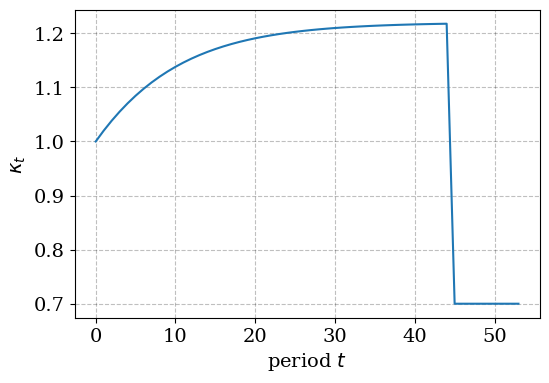

In [13]:
fig, ax = plt.subplots(1,1,figsize=(6,4))

ax.plot(model.par.kappa)

ax.set_xlabel('period $t$')
ax.set_ylabel('$\\kappa_t$')

filepath = f"{folder}/BufferStockModel_kappa.svg"
plt.savefig(filepath, bbox_inches='tight')

## 3. <a id='toc3_'></a>[Convergence](#toc0_)

D = 0, algoname = DeepSimulate


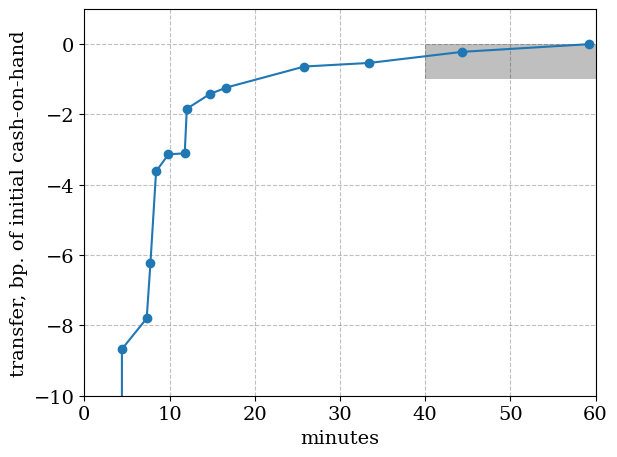

D = 0, algoname = DeepFOC


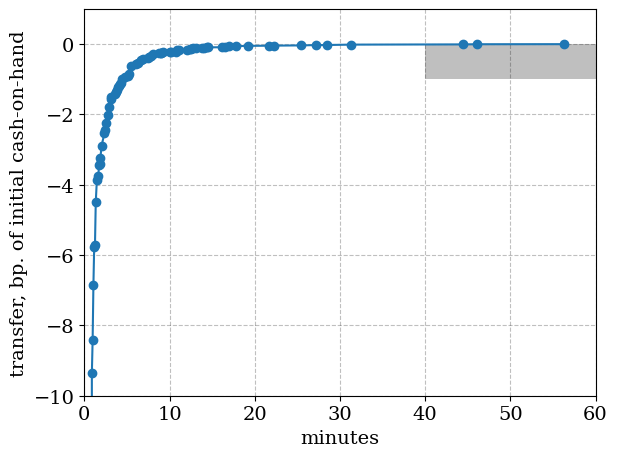

D = 3, algoname = DeepSimulate


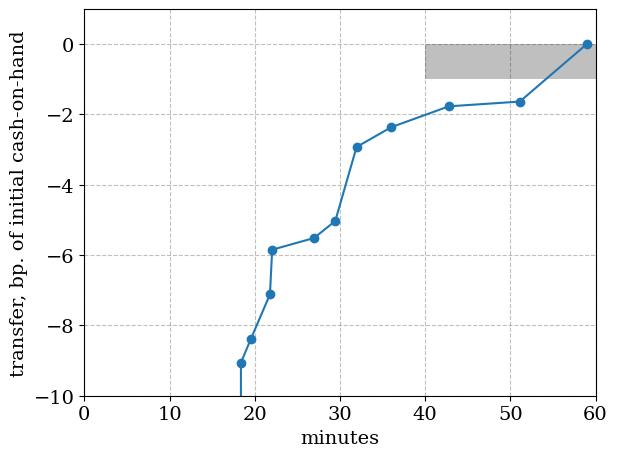

D = 3, algoname = DeepFOC


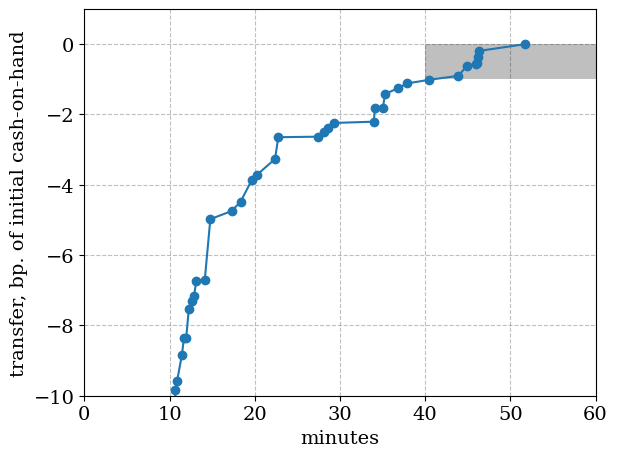

In [14]:
for D in Ds:
    for algoname in algonames:
        
        print(f'D = {D}, algoname = {algoname}')
        
        model = get_model(models,algoname,D)
        postfix = f'_BufferStockModel_{algoname}_{D}D'

        EconDLSolvers.convergence_plot(model,
                         y_fac=10_000,ylabel='transfer, bp. of initial cash-on-hand',
                         folder=folder,postfix=postfix,close_fig=False)
        
        plt.show()

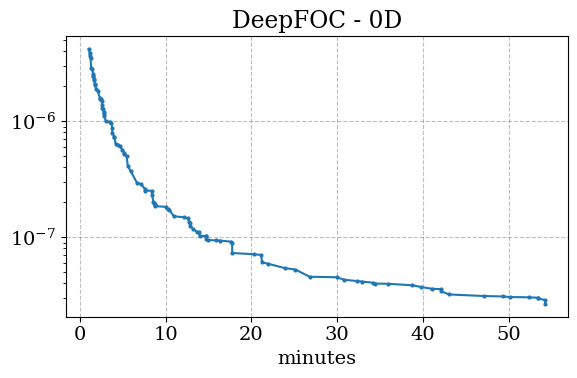

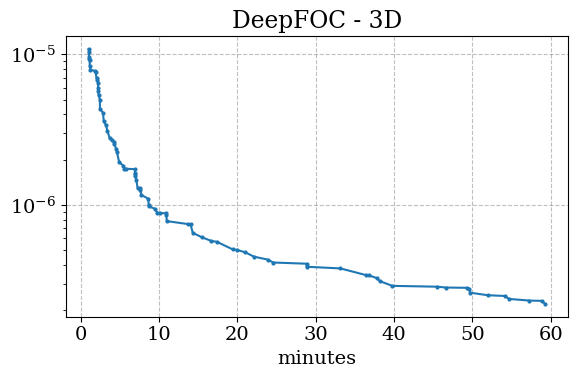

In [15]:
for D in [0,3]:
        
    model = get_model(models,'DeepFOC',D)
    k_max = model.info['iter']

    x = [model.info[('k_time',k)]/60 for k in range(k_max) if ('policy_loss',k) in model.info and model.info[('k_time',k)]/60 > 1]    
    y = [model.info[('policy_loss',k)] for k in range(k_max) if ('policy_loss',k) in model.info and model.info[('k_time',k)]/60 > 1]

    x_ = []
    y_ = []
    best_yi = np.inf
    for xi,yi in zip(x,y):
        if yi < best_yi:
            x_.append(xi)
            y_.append(yi)
            best_yi = yi

    fig, ax = plt.subplots(1,1,figsize=(6,4))
    ax.set_title(f'DeepFOC - {D}D')
    ax.plot(x_,y_,'-o',ms='2',color=colors[0])
    ax.set_xlabel('minutes')
    ax.set_yscale('log')

    fig.tight_layout()
    fig.savefig(f'{folder}/BufferStockModel_DeepFOC_{D}D_policy_loss.svg')

    plt.show()


## 4. <a id='toc4_'></a>[Solution comparisons](#toc3_)                            [&#8593;](#toc0_)

### 4.1. <a id='toc4_1_'></a>[Policy function](#toc3_1_)                            [&#8593;](#toc0_)

In [16]:
do_display = True
D = 0
t = 5
i_ps = [20,25,30]
i_p = i_ps[1]
m_max = 7.0
c_max = 3.0

m_grid = models[('DP','0D')].egm.m_grid
p_grid = models[('DP','0D')].egm.p_grid

DeepSimulate


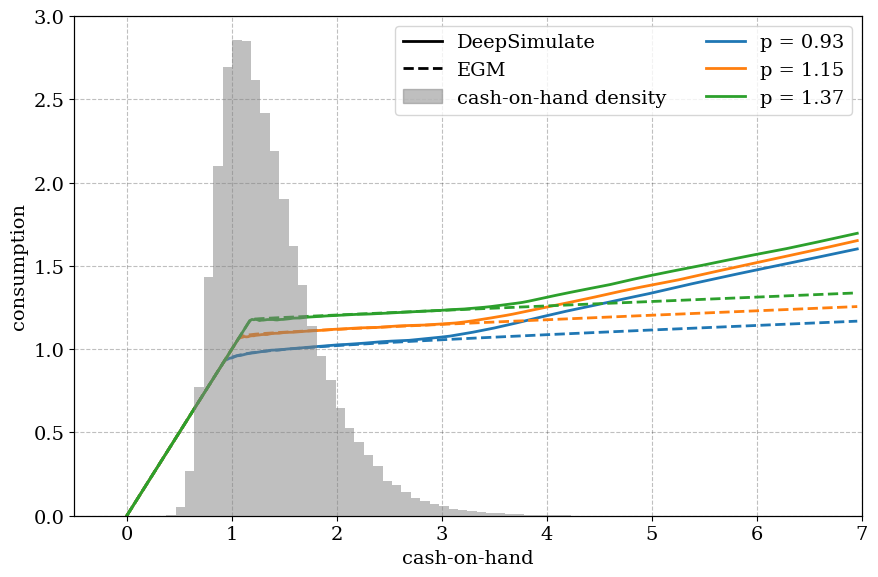

DeepFOC


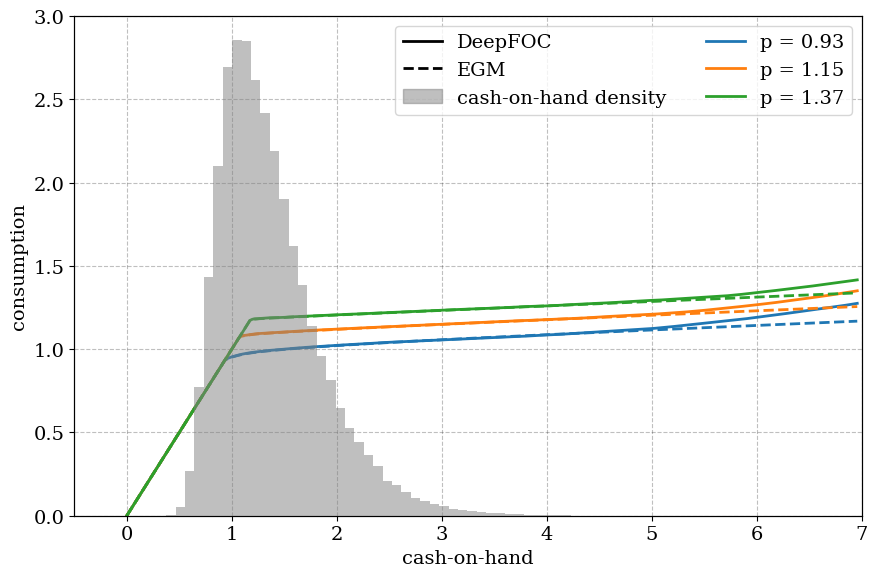

In [17]:
I = m_grid < m_max
for algoname in algonames:
    
    print(algoname)
    label = algoname
    model = get_model(models,algoname,D)

    fig = plt.figure(figsize=(9,6))
    ax = fig.add_subplot(1,1,1)
    for i,i_p in enumerate(i_ps):

        ax.plot(m_grid[I],models[('DP','0D')].egm.sol_con[t,i_p,0,0,0,I],color=colors[i],ls='--',lw=2)
        ax.plot(m_grid[I],model.info['sol_con_grid'][t,i_p,0,0,0,I],color=colors[i],lw=2)            

    # add histogram
    cash_in_hand = models[('DP','0D')].sim.states[t,:,0]
    twin_ax = ax.twinx()
    twin_ax.hist(cash_in_hand,bins=50,alpha=0.5,color='grey',density=True)
    twin_ax.set_yticks([])
    twin_ax.grid(False)

    # misc
    ax.set_xlim(-0.5,m_max)
    ax.set_xlabel('cash-on-hand')
    ax.set_ylim(0,c_max)
    ax.set_ylabel('consumption')

    # legend
    legend_labels = [label] + ['EGM'] + ['cash-on-hand density'] + [f'p = {p_grid[i_p]:.2f}' for i_p in i_ps] 
    legend_handles = [mlines.Line2D([0],[0],color='black',lw=2,ls='-')]
    legend_handles += [mlines.Line2D([0],[0],color='black',ls='--',lw=2)]
    legend_handles += [mpatches.Rectangle((0,0),1,1,color='grey',alpha=0.5)] 
    legend_handles += [mlines.Line2D([0],[0],color=colors[i],ls='-',lw=2) for i in range(3)] 
    ax.legend(legend_handles,legend_labels,ncol=2,loc='upper right')
    
    fig.tight_layout()
    filepath = f'{folder}/BufferStockModel_policy_0D_t{t}_{algoname}.svg'
    fig.savefig(filepath)

    if do_display: 
        plt.show()
    else:
        plt.close(fig)
        display(HTML(f'<a href="{filepath}">{filepath}</a>'))

### 4.2. <a id='toc4_2_'></a>[Exploration](#toc0_)

DeepSimulate


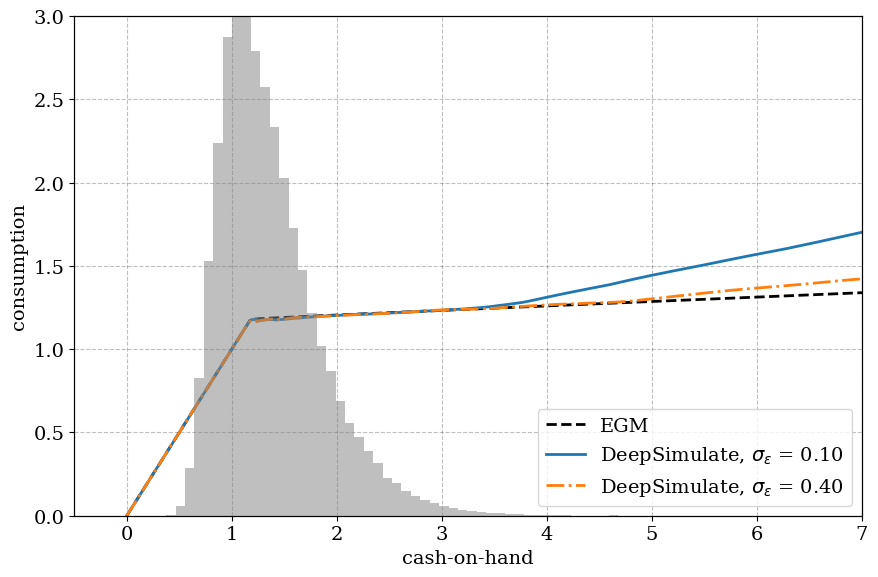

DeepFOC


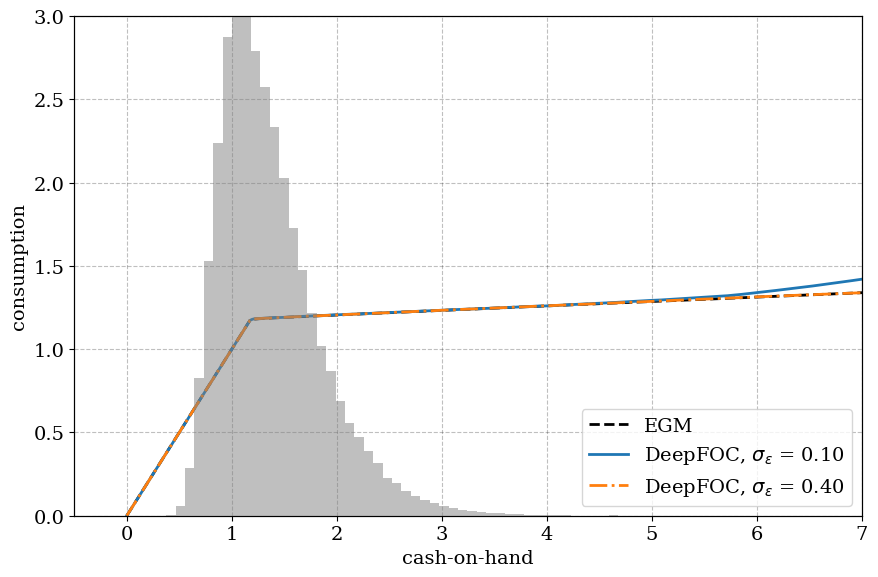

In [18]:
for algoname in algonames:

    print(algoname)

    fig = plt.figure(figsize=(9,6))
    ax = fig.add_subplot(1,1,1)

    ax.plot(m_grid,models[('DP','0D')].egm.sol_con[t,i_p,0,0,0,:],ls='--',lw=2,color='black',label='EGM')

    epsilon_sigma = models[(algoname,'0D')].train.epsilon_sigma[0] 
    ax.plot(m_grid,models[(algoname,'0D')].info['sol_con_grid'][t,i_p,0,0,0,:],
            ls='-',lw=2,label=f'{algoname}, $\\sigma_{{\\epsilon}}$ = {epsilon_sigma:.2f}')  

    model_ = models[(algoname,'0D',f'moreexplore')]
    epsilon_sigma = model_.train.epsilon_sigma[0]
    ax.plot(m_grid,model_.info['sol_con_grid'][t,i_p,0,0,0,:],
            ls='-.',lw=2,label=f'{algoname}, $\\sigma_{{\\epsilon}}$ = {epsilon_sigma:.2f}')  

    # add histogram
    cash_on_hand = models[('DP','0D')].sim.states[t,:,0]
    twin_ax = ax.twinx()
    twin_ax.hist(cash_on_hand,bins=50,alpha=0.5,color='grey',density=True,
                 label='cash-on-hand (right axis)')
    twin_ax.set_ylim(0,1.0)
    twin_ax.set_yticks([])
    twin_ax.grid(False)

    # misc
    ax.set_xlim(-0.5,m_max)
    ax.set_xlabel('cash-on-hand')
    ax.set_ylim(0,c_max)
    ax.set_ylabel('consumption')

    ax.legend(frameon=True,ncol=1,loc='lower right')

    fig.tight_layout()
    filepath = f'{folder}/BufferStockModel_policy_0D_t{t}_{algoname}_moreexplore.svg'   
    fig.savefig(filepath)

    if do_display: 
        plt.show()
    else:
        plt.close(fig)
        display(HTML(f'<a href="{filepath}">{filepath}</a>'))

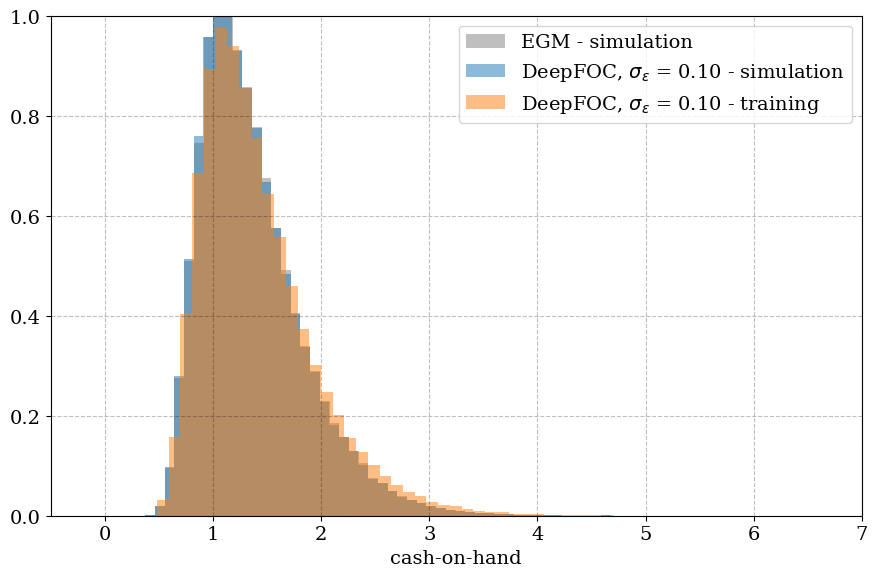

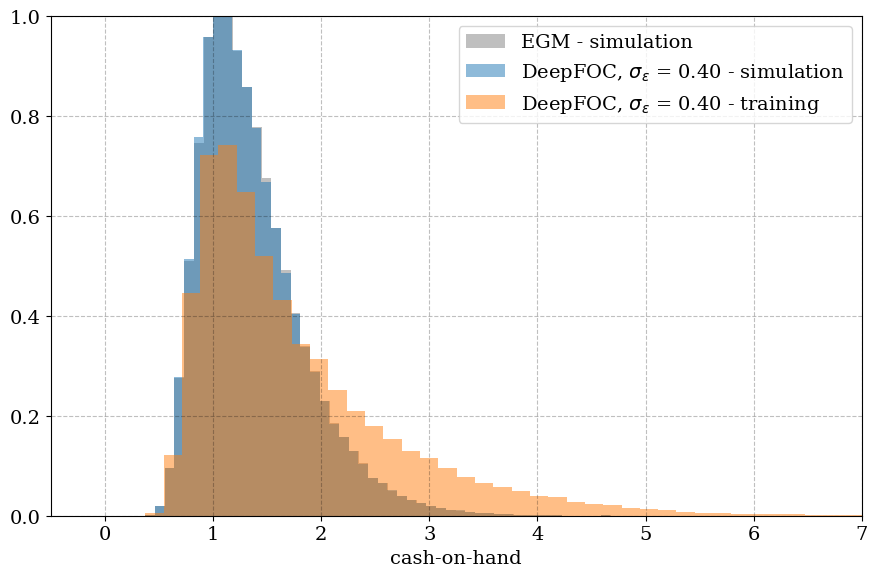

In [19]:
algoname = 'DeepFOC'
t = 5
for key in [(algoname,'0D'),(algoname,'0D','moreexplore')]:
    
    model = models[key]
    postfix = f'_{key[2]}' if len(key) == 3 else ''
    
    fig = plt.figure(figsize=(9,6))
    ax = fig.add_subplot(1,1,1)

    # EGM
    ax.hist(models[('DP','0D')].sim.states[t,:,0],bins=50,alpha=0.5,color='grey',density=True,label='EGM - simulation')

    # DL
    epsilon_sigma = model.train.epsilon_sigma[0] 
    ax.hist(model.sim.states[t,:,0],bins=50,alpha=0.5,density=True,
            label=f'{algoname}, $\\sigma_{{\\epsilon}}$ = {epsilon_sigma:.2f} - simulation')
    ax.hist(model.sim_eps.states[t,:,0],bins=50,alpha=0.5,density=True,
            label=f'{algoname}, $\\sigma_{{\\epsilon}}$ = {epsilon_sigma:.2f} - training')

    # misc
    ax.set_xlim(-0.5,m_max)
    ax.set_xlabel('cash-on-hand')
    ax.set_ylim(0,1.0)

    ax.legend(frameon=True,loc='upper right')

    fig.tight_layout()
    filepath = f'{folder}/BufferStockModel_policy_0D_t{t}_{algoname}_hist{postfix}.svg'
    fig.savefig(filepath)

    if do_display: 
        plt.show()
    else:
        plt.close(fig)
        display(HTML(f'<a href="{filepath}">{filepath}</a>'))

### 4.3. <a id='toc4_3_'></a>[Life cycle profiles](#toc3_2_)                            [&#8593;](#toc0_)

#### 4.3.1. <a id='toc4_3_1_'></a>[Cash-on-hand](#toc0_)

Wide format:

In [20]:
def plot_life_cycle_wide(varname,algoname,D,models,do_display,label=None):

    model = get_model(models,algoname,D)
    if model is None: return
    label = algoname if label is None else label

    print(algoname,D)

    fig = plt.figure(figsize=(18,4))

    ax = fig.add_subplot(1,3,1)
    ax.plot(np.mean(model.sim.__dict__[varname],axis=1),color=colors[0],linewidth=2)
    ax.plot(np.mean(models[('DP',f'{D}D')].sim.__dict__[varname],axis=1),color=colors[1],linewidth=2,ls='--')
    ax.set_title('mean')
    ax.set_xlabel('period, $t$')
    ax.axvline(x=model.par.T_retired,linewidth=2, label='retirement',color='black',linestyle='--')    
    ax.set_ylabel('cash-on-hand')

    ax = fig.add_subplot(1,3,2)
    ax.plot(np.percentile(model.sim.__dict__[varname],q=5,axis=1),color=colors[0],linewidth=2)
    ax.plot(np.percentile(models[('DP',f'{D}D')].sim.__dict__[varname],q=5,axis=1),color=colors[1],linewidth=2,ls='--')
    ax.set_title('5th percentile')
    ax.set_xlabel('period,$t$')
    ax.axvline(x=model.par.T_retired,linewidth=2, label='retirement',color='black',linestyle='--')
    ax.set_ylabel('cash-on-hand')

    ax = fig.add_subplot(1,3,3)
    ax.plot(np.percentile(model.sim.__dict__[varname],q=95,axis=1),label=label,color=colors[0],linewidth=2)
    ax.plot(np.percentile(models[('DP',f'{D}D')].sim.__dict__[varname],q=95,axis=1),label='EGM',color=colors[1],linewidth=2,ls='--')
    ax.set_title('95th percentile')
    ax.set_xlabel('period,$t$')
    ax.axvline(x=model.par.T_retired,linewidth=2, label='retirement',color='black',linestyle='--')
    ax.set_ylabel('cash-on-hand') 
    # high legend alpha
    ax.legend(loc='lower right',framealpha=0.95)

    fig.tight_layout()

    filepath = f'{folder}/BufferStockModel_lcp_{varname}_{D}D_{algoname}_wide.svg'
    fig.savefig(filepath)

    if do_display: 
        plt.show()
    else:
        plt.close(fig)
        display(HTML(f'<a href="{filepath}">{filepath}</a>'))

DeepSimulate 0


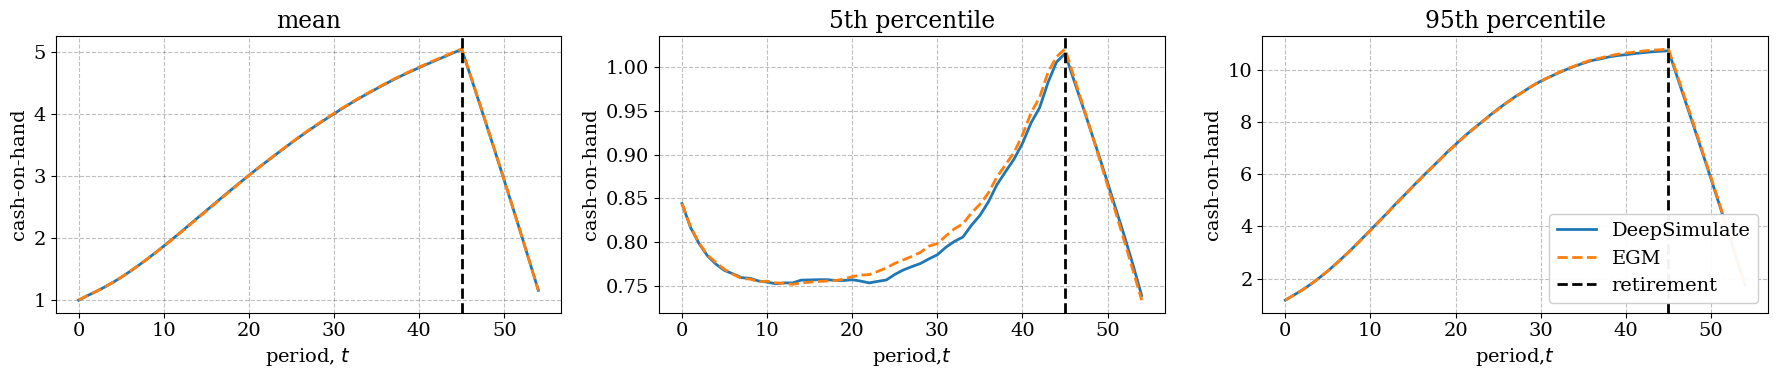

DeepFOC 0


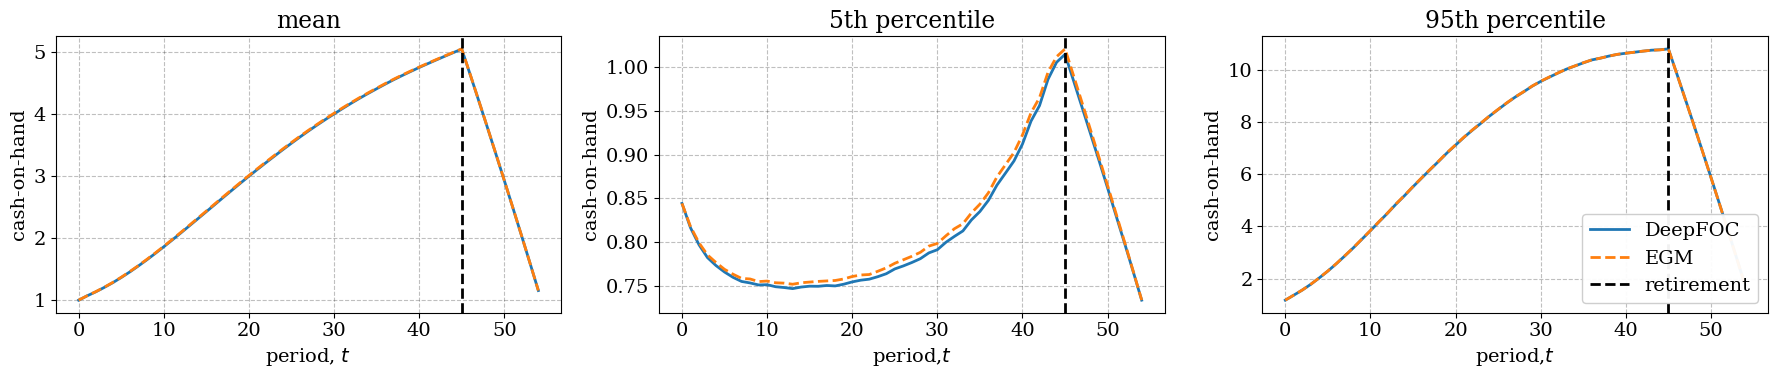

DeepSimulate 3


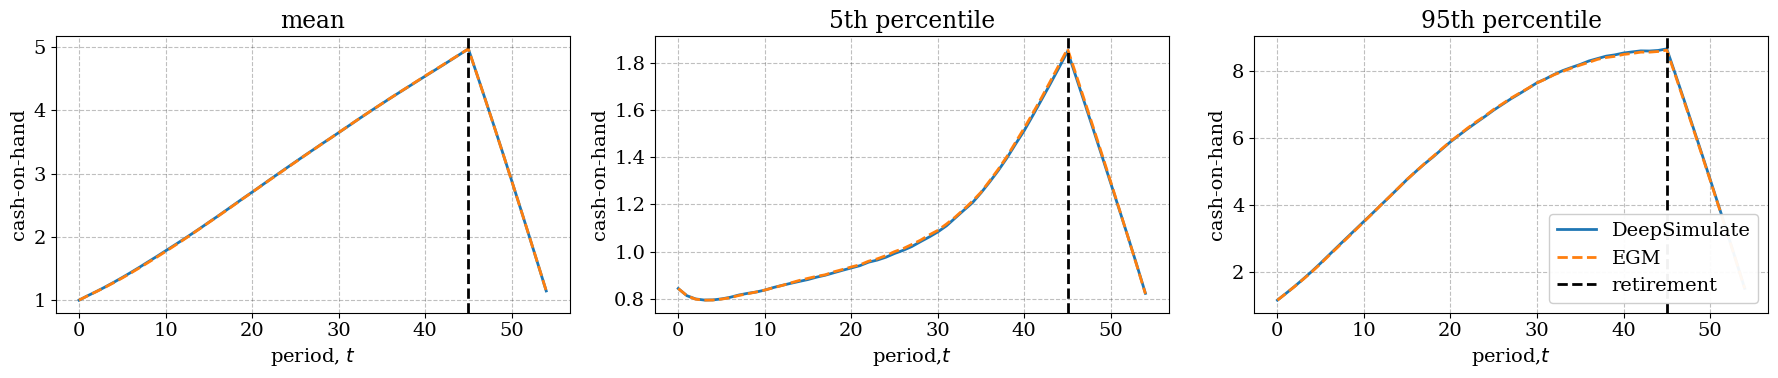

DeepFOC 3


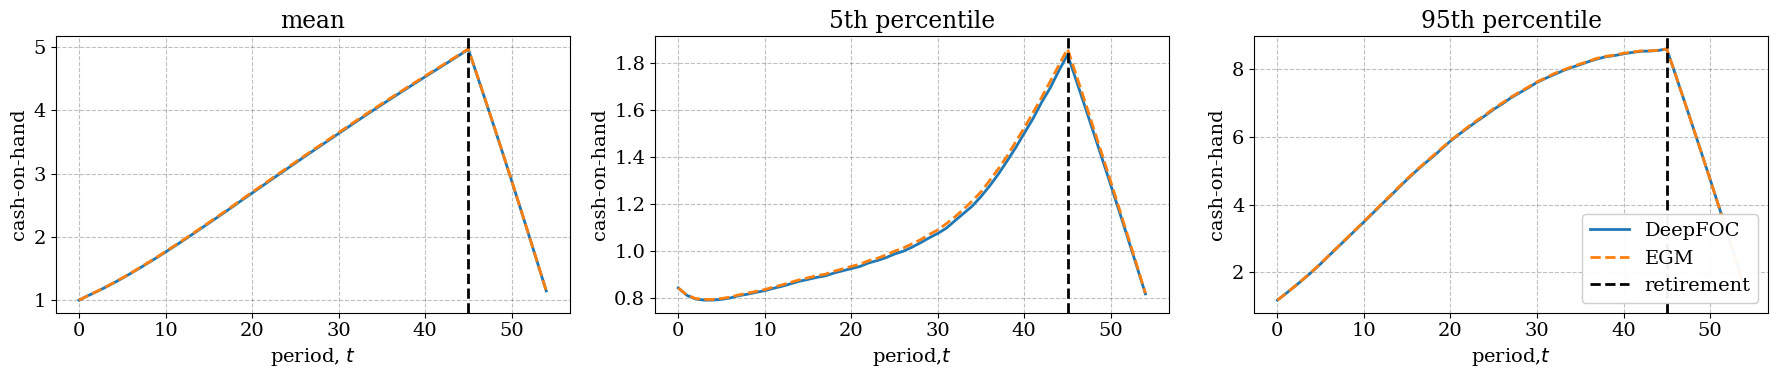

In [21]:
varname = 'm'
do_display = True
for D in Ds:
    for algoname in algonames:
        plot_life_cycle_wide(varname,algoname,D,models,do_display)

Long format:

In [22]:
def plot_life_cycle_long(varname,algoname,D,models,do_display):

    model = get_model(models,algoname,D)
    if model is None: return
    label = algoname
    print(algoname,D)

    fig = plt.figure(figsize=(18,15))

    ax = fig.add_subplot(3,1,1)
    ax.plot(np.mean(model.sim.__dict__[varname],axis=1),label=label,color=colors[0],linewidth=2)
    ax.plot(np.mean(models[('DP',f'{D}D')].sim.__dict__[varname],axis=1),label='EGM',color=colors[1],linewidth=2,ls='--')
    ax.set_title('mean')
    ax.set_xlabel('period, $t$')
    ax.axvline(x=model.par.T_retired,linewidth=2, label='retirement',color='black',linestyle='--')
    ax.legend()
    ax.set_ylabel('cash-on-hand')

    ax = fig.add_subplot(3,1,2)
    ax.plot(np.percentile(model.sim.__dict__[varname],q=5,axis=1),color=colors[0],linewidth=2)
    ax.plot(np.percentile(models[('DP',f'{D}D')].sim.__dict__[varname],q=5,axis=1),color=colors[1],linewidth=2,ls='--')
    ax.set_title('5th percentile')
    ax.set_xlabel('period,$t$')
    ax.axvline(x=model.par.T_retired,linewidth=2, label='retirement',color='black',linestyle='--')
    ax.set_ylabel('cash-on-hand')

    ax = fig.add_subplot(3,1,3)
    ax.plot(np.percentile(model.sim.__dict__[varname],q=95,axis=1),color=colors[0],linewidth=2)
    ax.plot(np.percentile(models[('DP',f'{D}D')].sim.__dict__[varname],q=95,axis=1),color=colors[1],linewidth=2,ls='--')
    ax.set_title('95th percentile')
    ax.set_xlabel('period,$t$')
    ax.axvline(x=model.par.T_retired,linewidth=2, label='retirement',color='black',linestyle='--')
    ax.set_ylabel('cash-on-hand')        

    fig.tight_layout()

    filepath = f'{folder}/BufferStockModel_lcp_m_{D}D_{algoname}_long.svg'
    fig.savefig(filepath)

    plt.close(fig)
    display(HTML(f'<a href="{filepath}">{filepath}</a>'))    

In [23]:
varname = 'm'
do_display = False
for D in Ds:
    for algoname in algonames:
        plot_life_cycle_long(varname,algoname,D,models,do_display)


DeepSimulate 0


DeepFOC 0


DeepSimulate 3


DeepFOC 3


#### 4.3.2. <a id='toc4_3_2_'></a>[MPCs](#toc0_)

In [24]:
for D in Ds:
    for algoname in algonames:

        model = get_model(models,algoname,D)
        if model is None: continue
        label = algoname
        print(algoname,D)

        fig = plt.figure(figsize=(18,4))

        ax = fig.add_subplot(1,3,1)
        ax.plot(np.mean(model.sim.MPC[:-1,:],axis=1),label=label,color=colors[0],linewidth=2)
        ax.plot(np.mean(models[('DP',f'{D}D')].sim.MPC[:-1,:],axis=1),label='EGM',color=colors[1],linewidth=2,ls='--')
        ax.set_title('mean')
        ax.set_xlabel('period, $t$')
        ax.axvline(x=model.par.T_retired,linewidth=2, label='retirement',color='black',linestyle='--')
        ax.legend(loc='upper center',framealpha=0.95)
        ax.set_ylabel('MPC')

        ax = fig.add_subplot(1,3,2)
        ax.plot(np.percentile(model.sim.MPC[:-1,:],q=5,axis=1),color=colors[0],linewidth=2)
        ax.plot(np.percentile(models[('DP',f'{D}D')].sim.MPC[:-1,:],q=5,axis=1),color=colors[1],linewidth=2,ls='--')
        ax.set_title('5th percentile')
        ax.set_xlabel('period,$t$')
        ax.axvline(x=model.par.T_retired,linewidth=2, label='retirement',color='black',linestyle='--')
        ax.set_ylabel('MPC')

        ax = fig.add_subplot(1,3,3)
        ax.plot(np.percentile(model.sim.MPC[:-1,:],q=95,axis=1),color=colors[0],linewidth=2)
        ax.plot(np.percentile(models[('DP',f'{D}D')].sim.MPC[:-1,:],q=95,axis=1),color=colors[1],linewidth=2,ls='--')
        ax.set_title('95th percentile')
        ax.set_xlabel('period,$t$')
        ax.axvline(x=model.par.T_retired,linewidth=2, label='retirement',color='black',linestyle='--')
        ax.set_ylabel('MPC')        

        fig.tight_layout()

        filepath = f'{folder}/BufferStockModel_lcp_MPC_{D}D_{algoname}.svg'
        fig.savefig(filepath)

        if do_display: 
            plt.show()
        else:
            plt.close(fig)
            display(HTML(f'<a href="{filepath}">{filepath}</a>'))

DeepSimulate 0


DeepFOC 0


DeepSimulate 3


DeepFOC 3


### 4.4. <a id='toc4_4_'></a>[CDFs of cash-on-hand](#toc3_3_)                            [&#8593;](#toc0_)

In [25]:
def CDF(x):

    # sort data
    x = np.sort(x)
    
    # create y data
    y = np.arange(1, len(x)+1) / len(x)

    return x, y

In [26]:
m_max_high = 16

for D in Ds:
    for algoname in algonames:

        model = get_model(models,algoname,D)
        if model is None: continue
        label = algoname

        print(algoname,D)

        fig = plt.figure(figsize=(18,4))

        for i,t in enumerate([15,25,35]):
                
            ax = fig.add_subplot(1,3,1+i)

            x, y = CDF(model.sim.states[t,:,0])
    
            ax.plot(x,y,label=label,linewidth=2)           
                    
            x,y = CDF(models[('DP',f'{D}D')].sim.states[t,:,0])
        
            ax.plot(x,y,label=f'EGM',linewidth=2,color='black',linestyle='--')
        
            ax.set_xlim([0,m_max_high ])
            ax.set_xlabel('cash-on-hand')
            ax.set_xticks(np.arange(0,m_max_high +1,2))
            ax.set_ylabel('CDF')
            if i ==0: ax.legend(loc='lower right')
            ax.set_title(f't ={t}')

        fig.tight_layout()
        filepath = f'{folder}/BufferStockModel_cdf_{D}D_{algoname}.svg'
        fig.savefig(filepath)   

        if do_display: 
            plt.show()
        else:
            plt.close(fig)
            display(HTML(f'<a href="{filepath}">{filepath}</a>'))
            

DeepSimulate 0


DeepFOC 0


DeepSimulate 3


DeepFOC 3


### 4.5. <a id='toc4_5_'></a>[Cross-section](#toc0_)

In [27]:
def plot_cross_section(algoname,D,models,basename,N=10_000,ts=[15,25,35],label=None,do_display=True):
    
    baselabel = basename if not basename == 'DP' else 'EGM'
    label = algoname if label is None else label

    fig = plt.figure(figsize=(18,6))        
    for i_t,t in enumerate(ts):

        ax = fig.add_subplot(1,len(ts),1+i_t)

        m_base = get_model(models,basename,D).sim.states[t,:N,0]
        m_algo = get_model(models,algoname,D).sim.states[t,:N,0]
        
        # 45 degree
        ax.plot([0,m_max_high],[0,m_max_high],color='black',ls='-',lw=3,alpha=0.5,label='45 degree line')
        ax.set_title(f't={t}')

        # poly fit
        a,b,c,d = np.polyfit(m_base,m_algo,3)
        x_fit = np.linspace(0,m_max_high,1000)
        y_fit = a*x_fit**3 + b*x_fit**2 + c*x_fit + d
        ax.plot(x_fit,y_fit,color=colors[0],ls='-',lw=2,label='best cubic fit')

        # scatter
        ax.scatter(m_base,m_algo,color='black',s=5,label='agents',rasterized=True)
                
        # box            
        m_corr = np.corrcoef(m_base,m_algo)[0,1]
        m_abs_diff_rel = np.mean(np.abs((m_algo-m_base)/m_base))
        box_text = ''
        box_text += f'corr.: {m_corr:.3f}\n'
        box_text += f'mean abs. rel. diff: {m_abs_diff_rel:.3f}'
        ax.text(0.95*m_max_high,0.10*m_max_high,box_text,fontsize=11,bbox=dict(facecolor='white',alpha=0.75),ha='right')

        # details
        ax.set_xlim([0,m_max_high])
        ax.set_xticks(np.arange(0,m_max_high +1,2))
        ax.set_xlabel(f'cash-on-hand, {baselabel}')
        ax.set_ylim([0,m_max_high])
        ax.set_yticks(np.arange(0,m_max_high +1,2))
        ax.set_ylabel(f'cash-on-hand, {label}')

        from matplotlib.ticker import MaxNLocator
        loc = MaxNLocator(nbins=6)
        ax.xaxis.set_major_locator(loc)
        ax.yaxis.set_major_locator(loc)        

        if i_t == 0: ax.legend(loc='upper left')
        
    fig.tight_layout()
    fig.savefig(f'{folder}/BufferStockModel_cross_section_m_{D}D_{algoname}_{basename}.svg')
    
    if do_display: 
        plt.show()
    else:
        plt.close(fig)
        display(HTML(f'<a href="{filepath}">{filepath}</a>'))

DeepSimulate, D = 0 [basename = 'DP']


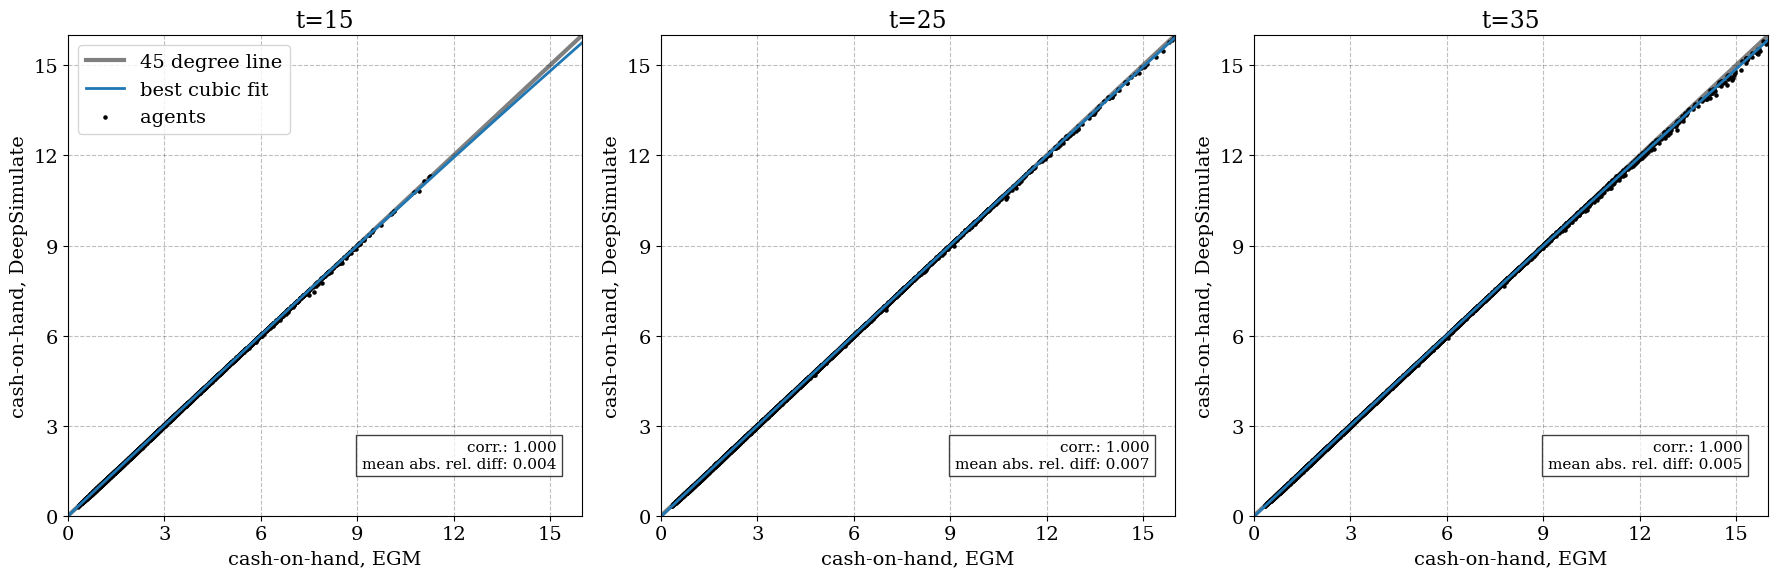

DeepSimulate, D = 3 [basename = 'DP']


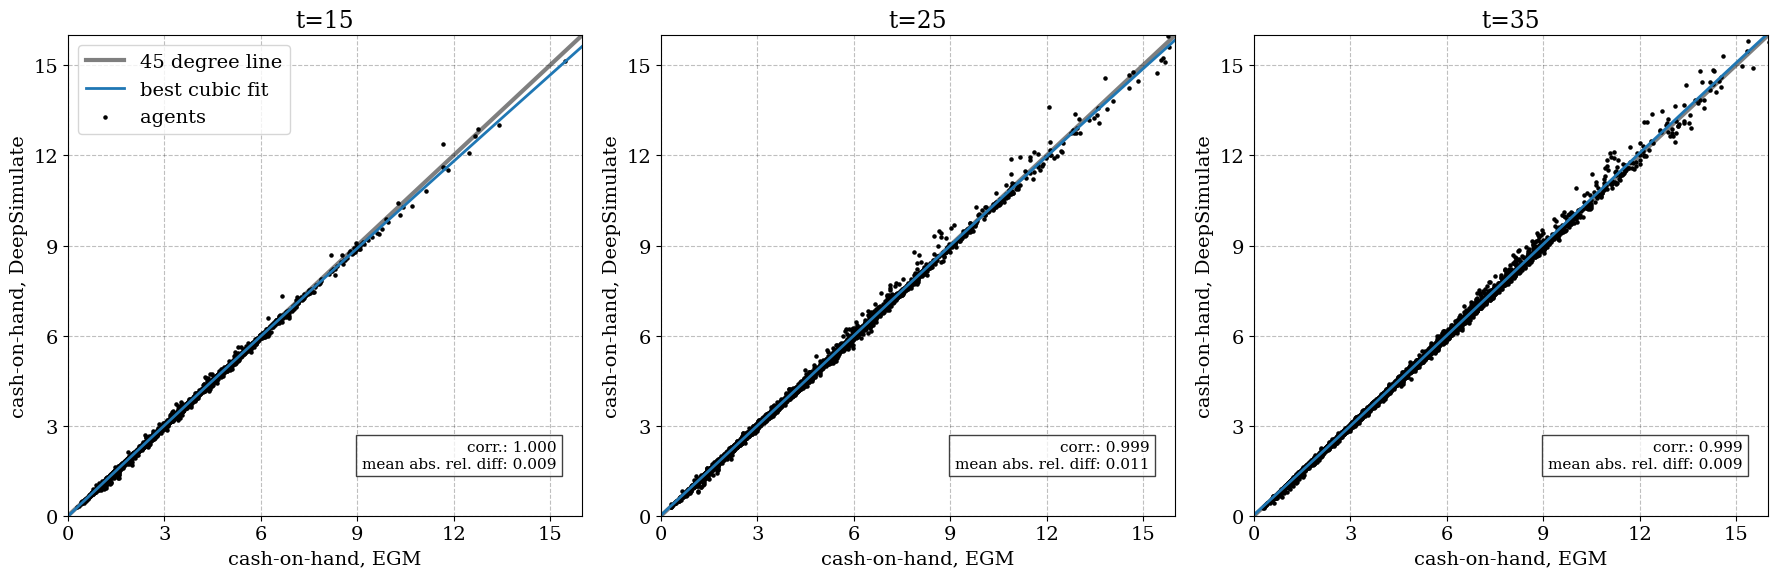

DeepFOC, D = 0 [basename = 'DP']


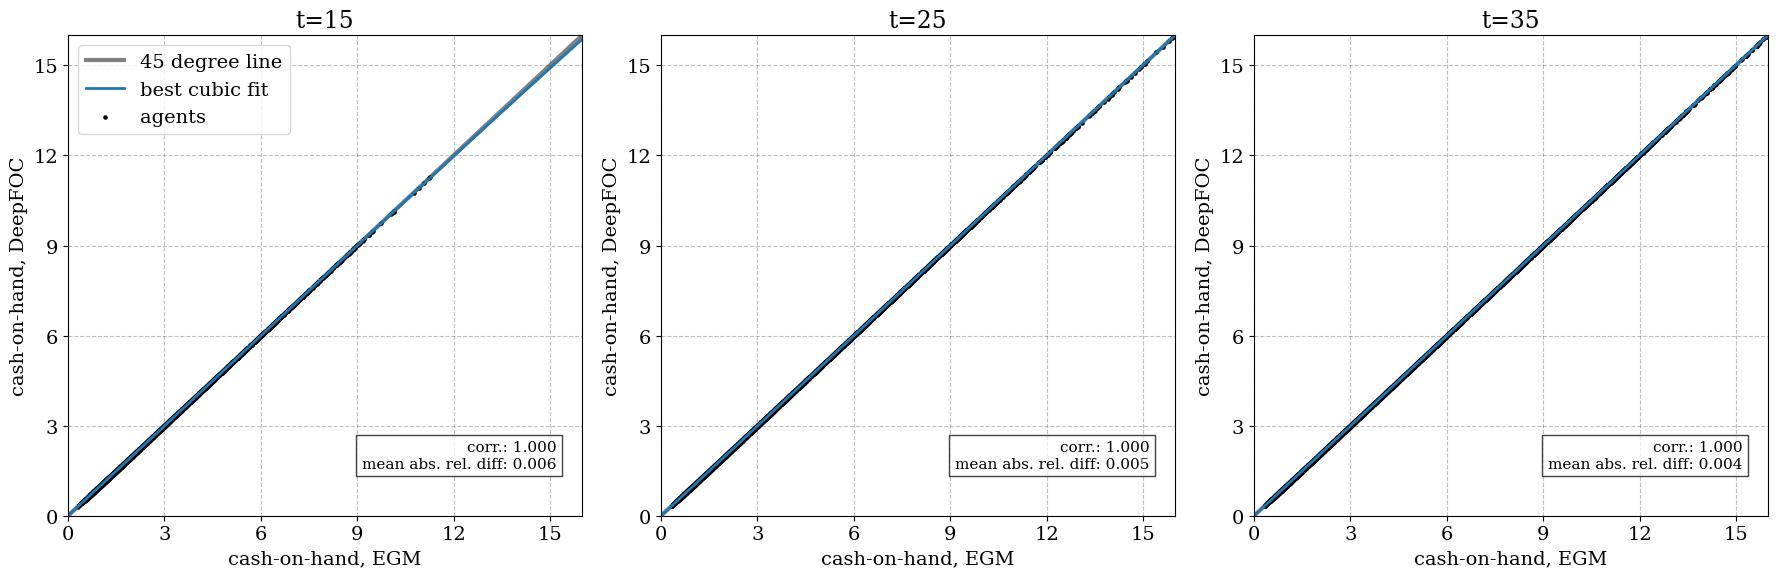

DeepFOC, D = 3 [basename = 'DP']


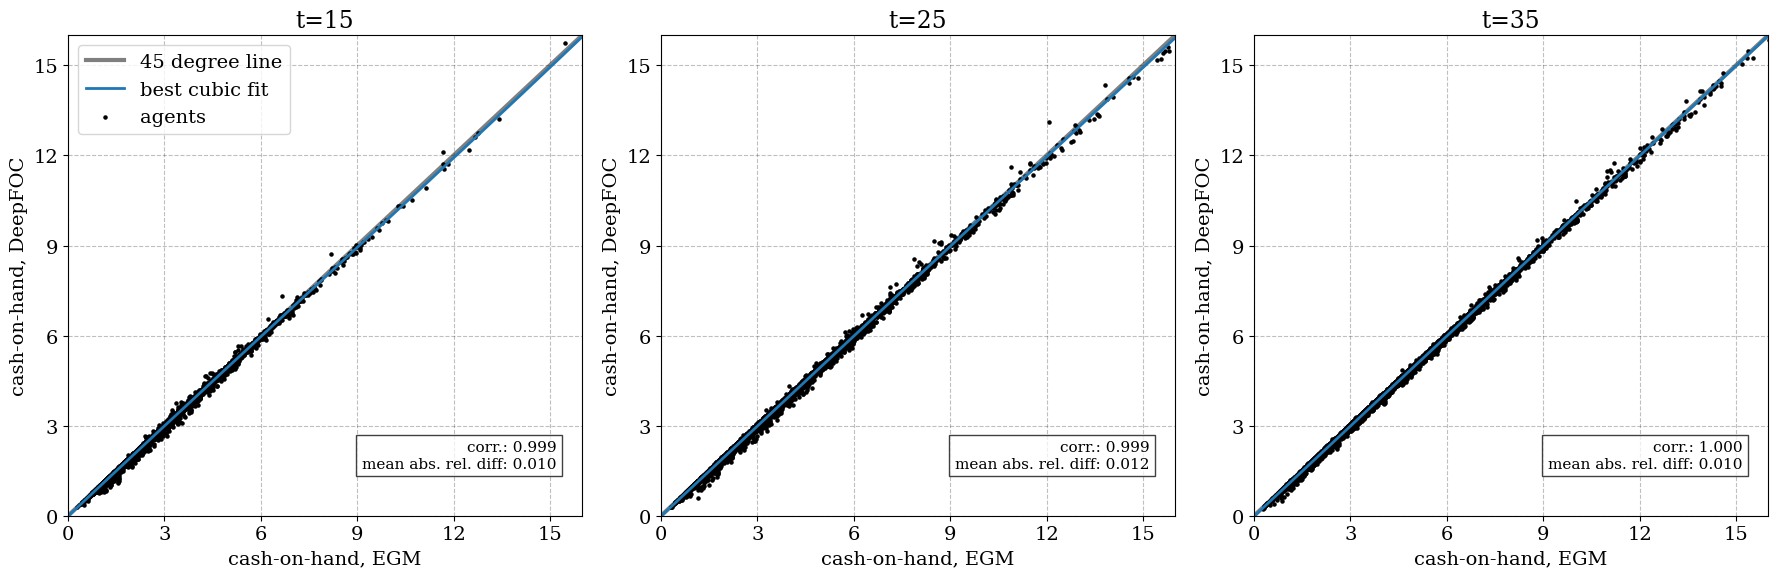

DeepFOC, D = 0 [basename = 'DeepSimulate']


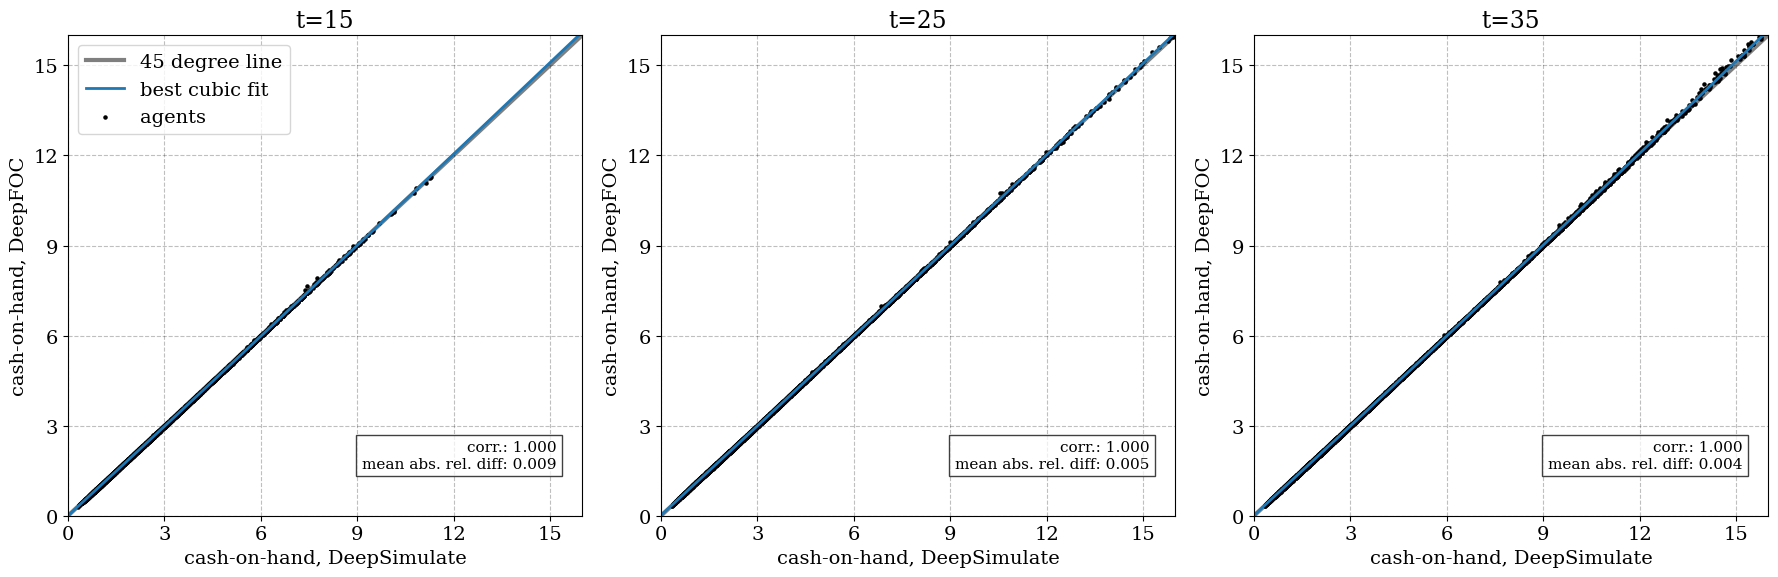

DeepFOC, D = 3 [basename = 'DeepSimulate']


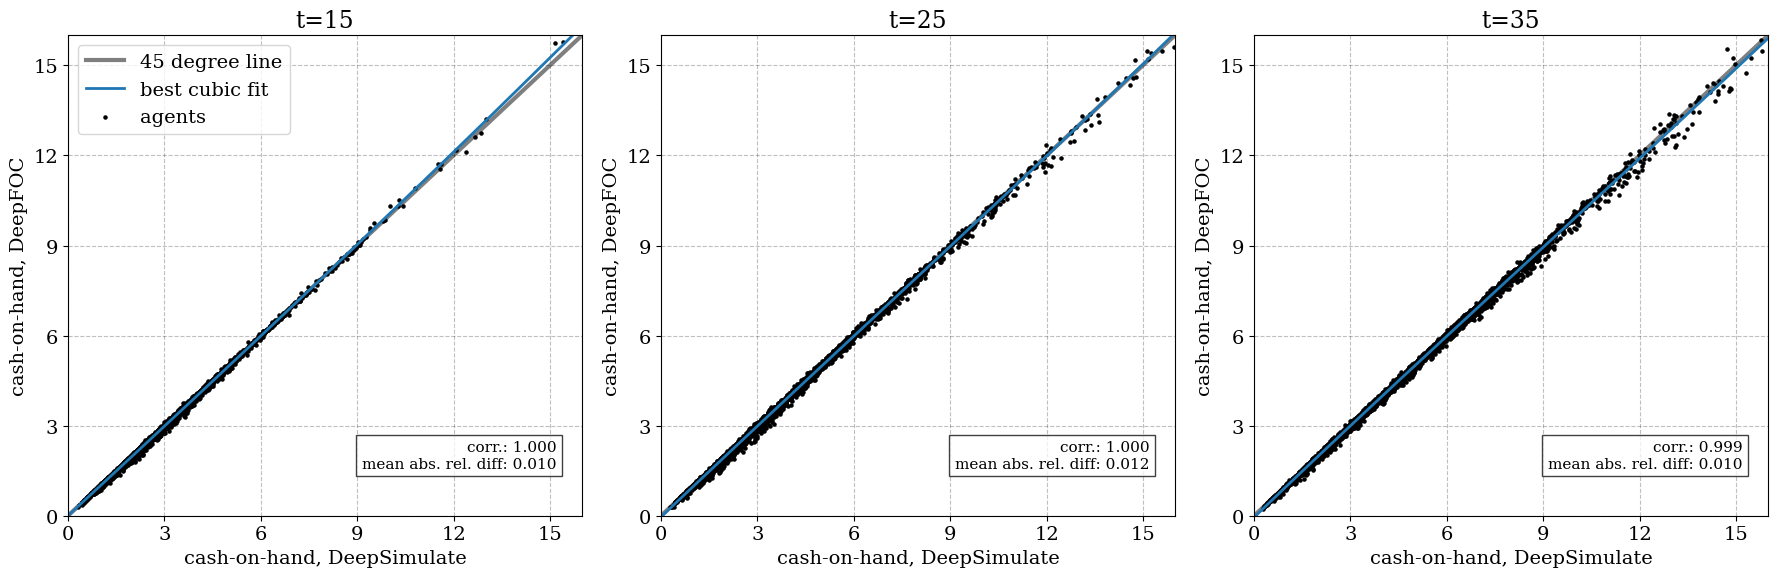

In [28]:
basenames = ['DP','DeepSimulate']
for basename in basenames:    
    for i_algo,algoname in enumerate(algonames):        
        for D in Ds:
            if algoname == basename: continue
            print(f'{algoname}, {D = } [{basename = }]')
            plot_cross_section(algoname,D,models,basename)

### 4.6. <a id='toc4_6_'></a>[Transfer](#toc0_)

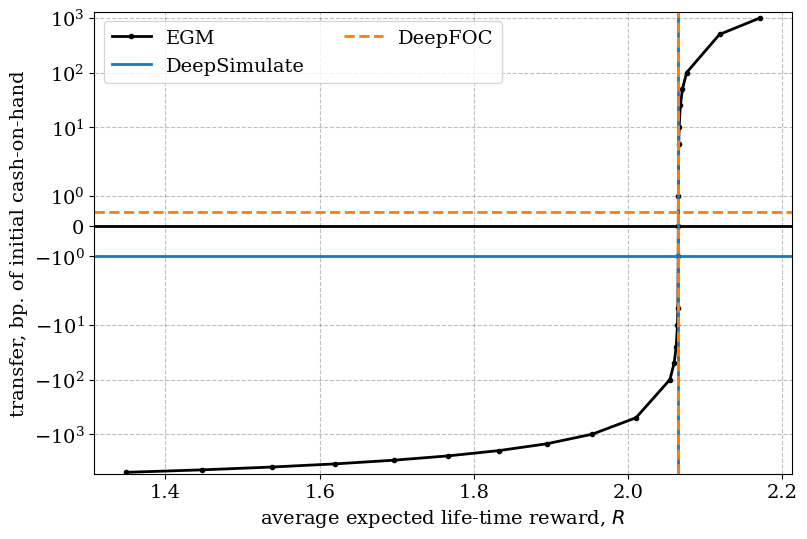

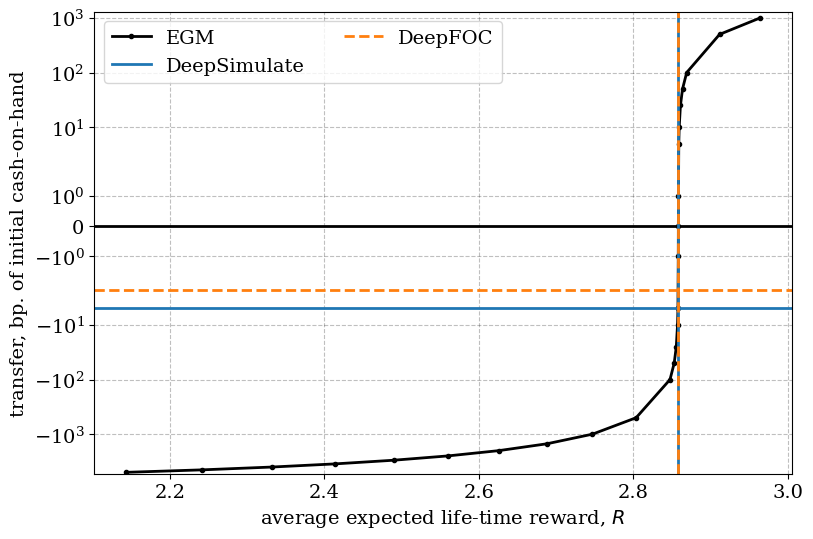

In [29]:
for D in Ds:
    transfer_plot('BufferStockModel',models,algonames,D,folder=folder)

## 5. <a id='toc5_'></a>[Speed-of-convergence](#toc0_)

In [30]:
xlim = [0.1,100]
xlim_low = [0.001,100]
ylim = [-1000,10]

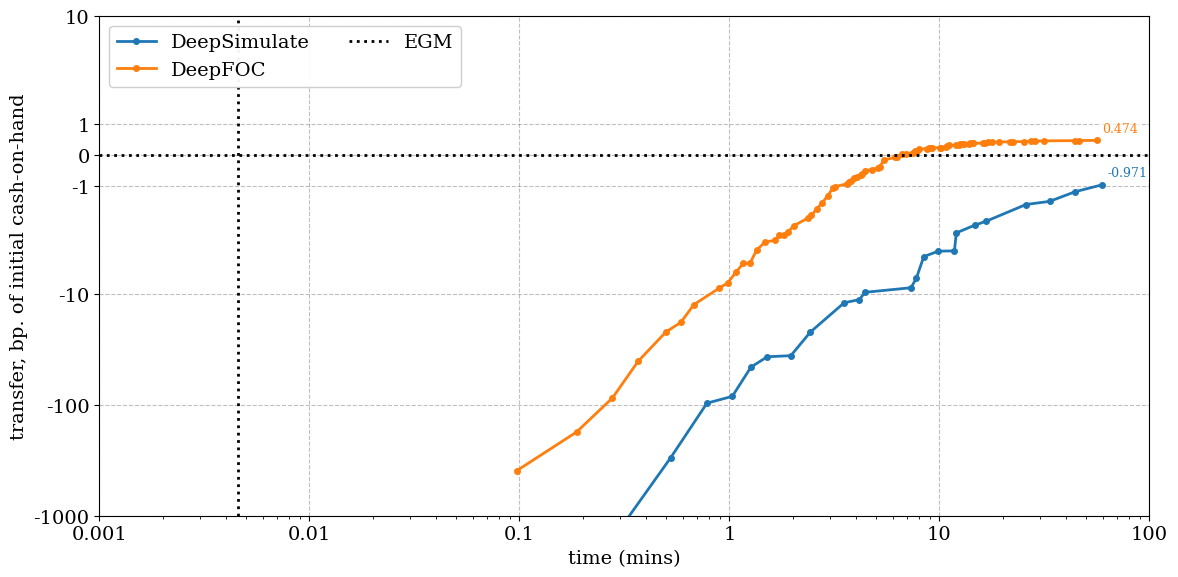

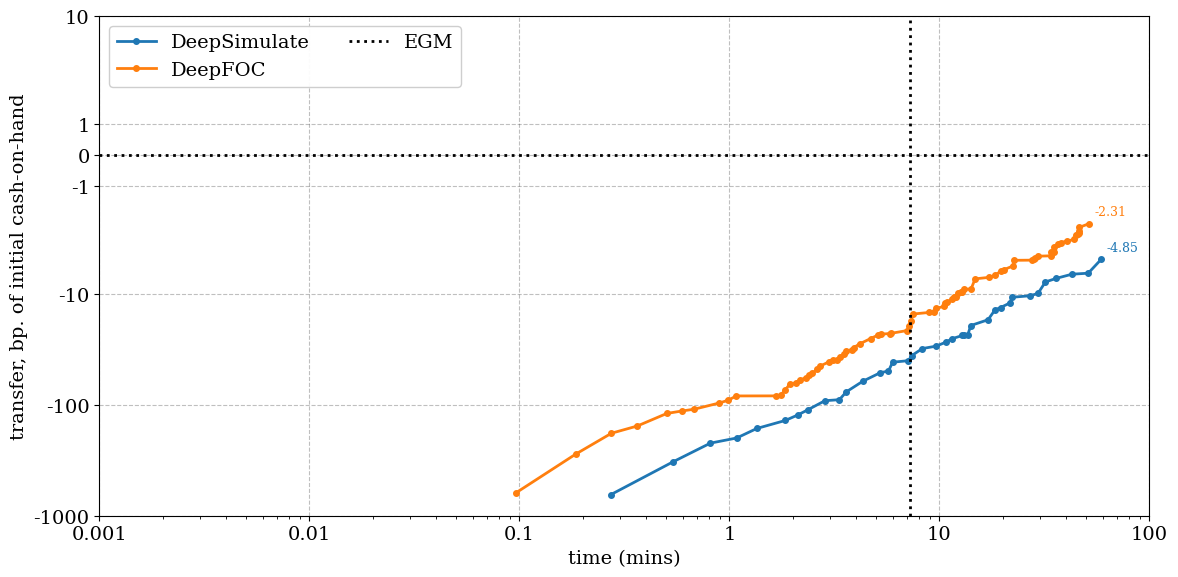

In [31]:
for D in Ds:
    
    Dstr = f'{D}D'

    DP = models[('DP',Dstr)]
    specs = {(algoname,Dstr):algoname for algoname in algonames}

    convergence_plot('BufferStockModel',models,specs,DP=DP,do_transfer=True,
                     xlim=xlim_low,ylim=ylim,
                     folder=folder,postfix=f'_{Dstr}')

Curse of dimensionality:

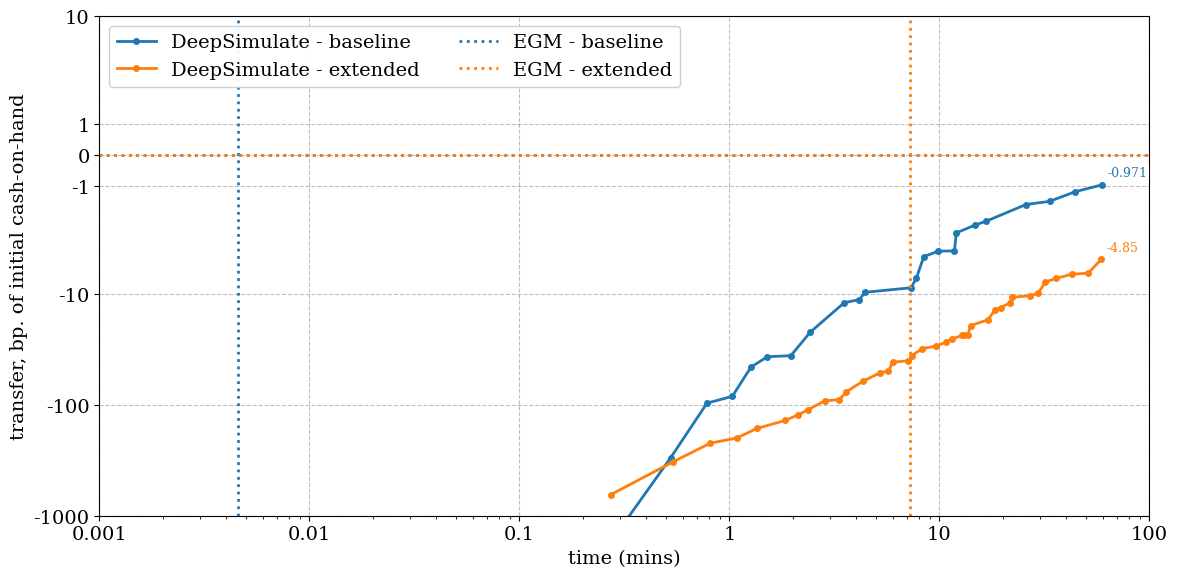

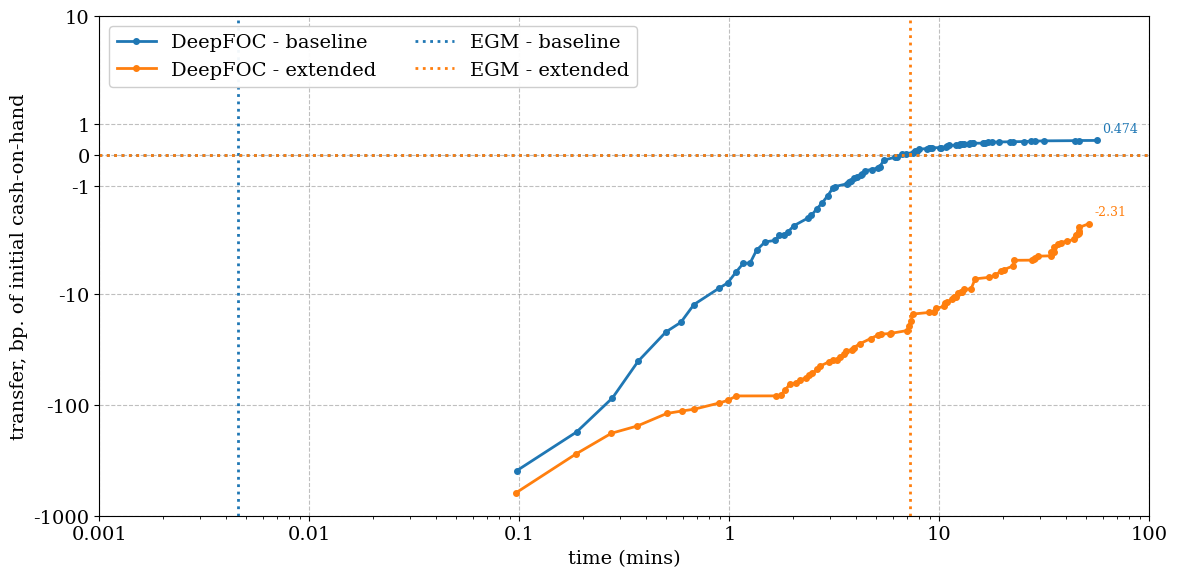

In [32]:
xlim_low = [0.001,100]
for algoname in algonames:
    
    DP = {
        ('DP',f'0D'):f'EGM - baseline',
        ('DP',f'3D'):f'EGM - extended',
    }

    specs = {
        (algoname,f'0D'):f'{algoname} - baseline',
        (algoname,f'3D'):f'{algoname} - extended',
    }

    convergence_plot('BufferStockModel',models,specs,DP=DP,do_transfer=True,
                     xlim=xlim_low,ylim=ylim,
                     folder=folder,postfix=f'_{algoname}')  

    plt.show()  

Show all:

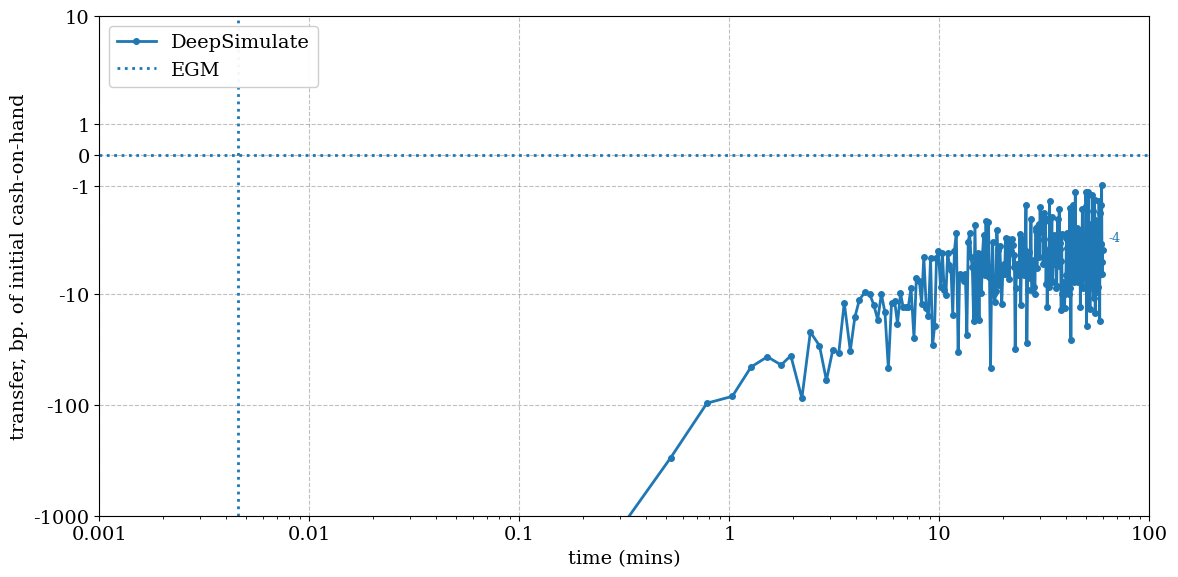

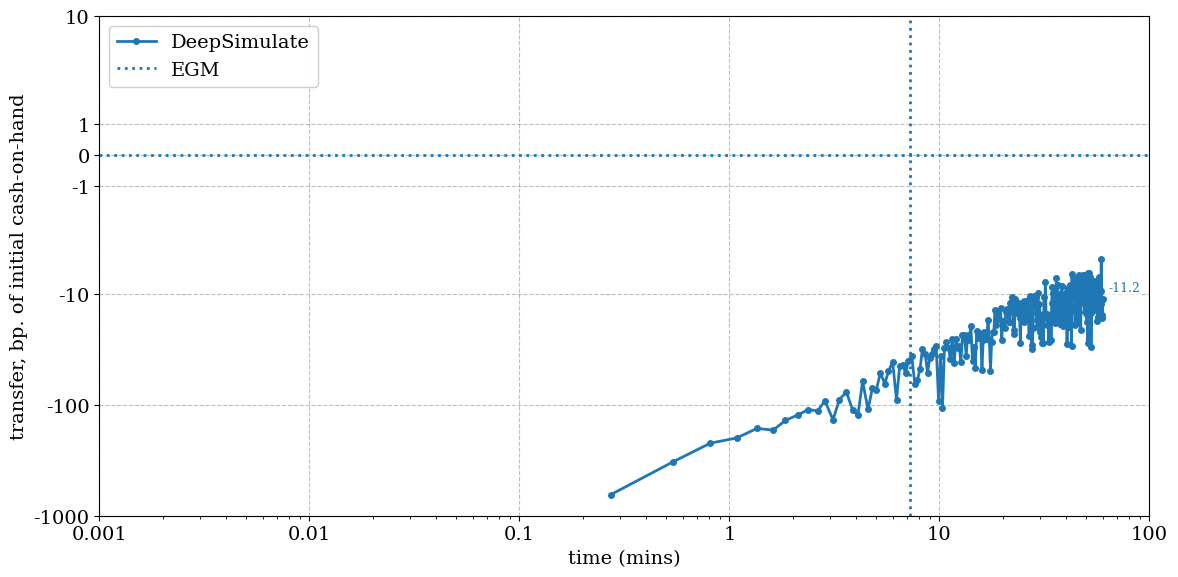

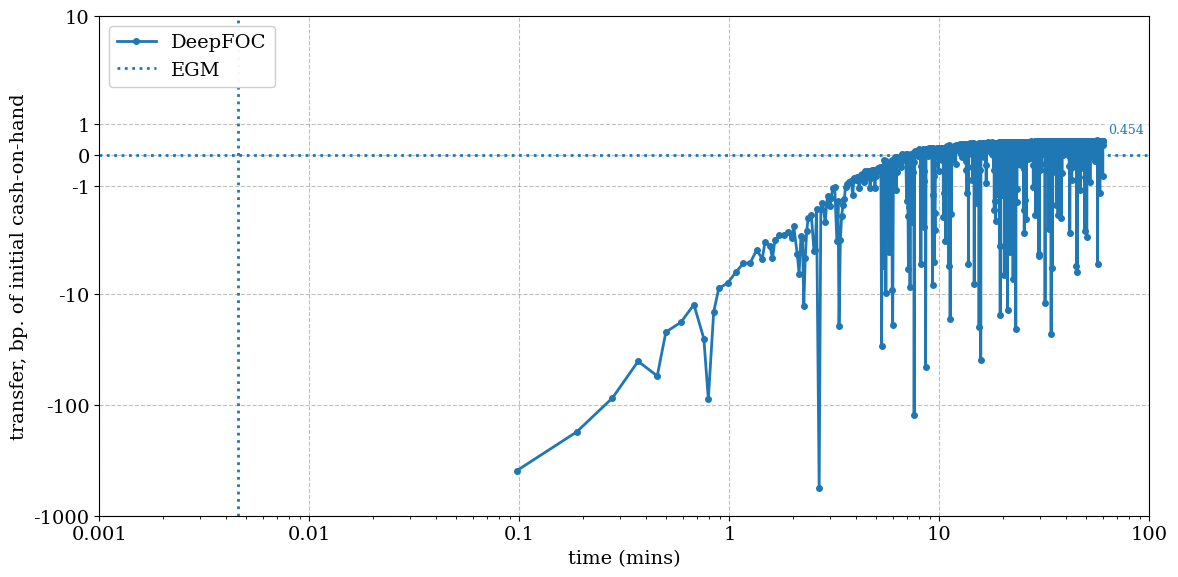

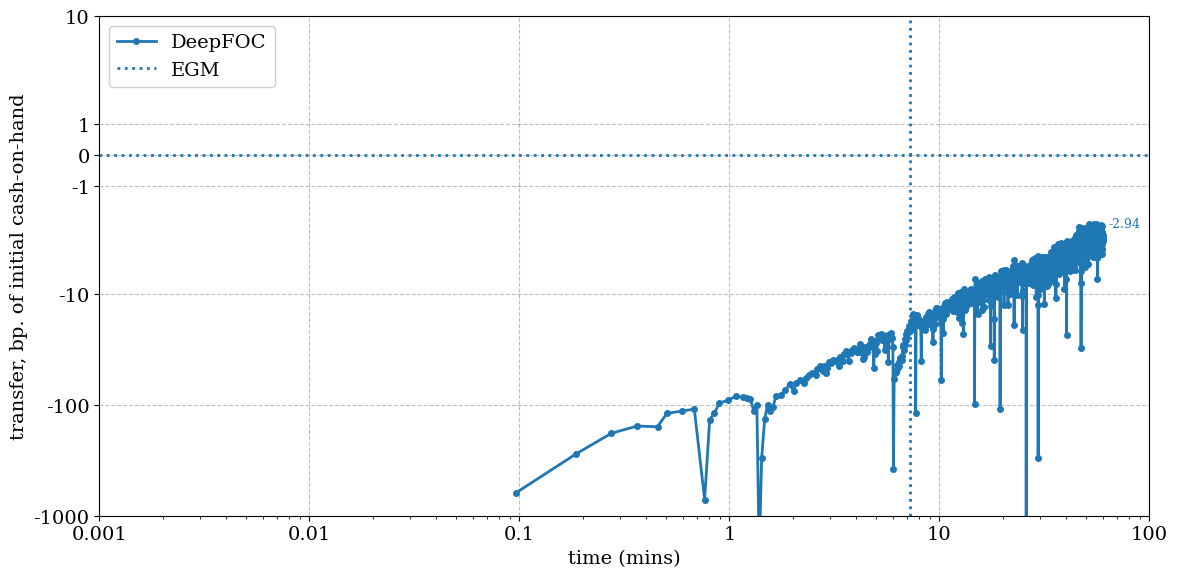

In [33]:
xlim_low = [0.001,100]
for algoname in algonames:
    for D in Ds:

        DP = {
            ('DP',f'{D}D'):f'EGM',
        }

        specs = {
            (algoname,f'{D}D'):f'{algoname}',
        }

        convergence_plot('BufferStockModel',models,specs,DP=DP,do_transfer=True,
                        xlim=xlim_low,ylim=ylim,legend_ncol=1,
                        folder=folder,postfix=f'_{algoname}_{D}D_show_all',show_all=True)

        plt.show()  

### 5.1. <a id='toc5_1_'></a>[Exploration](#toc0_)

DeepSimulate 0D


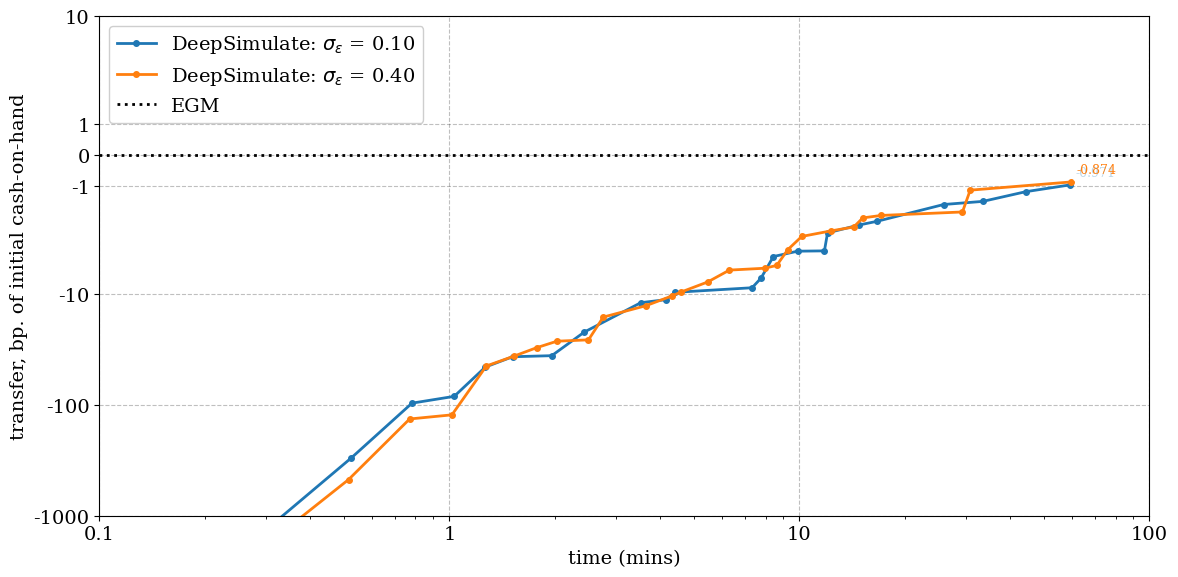

DeepFOC 0D


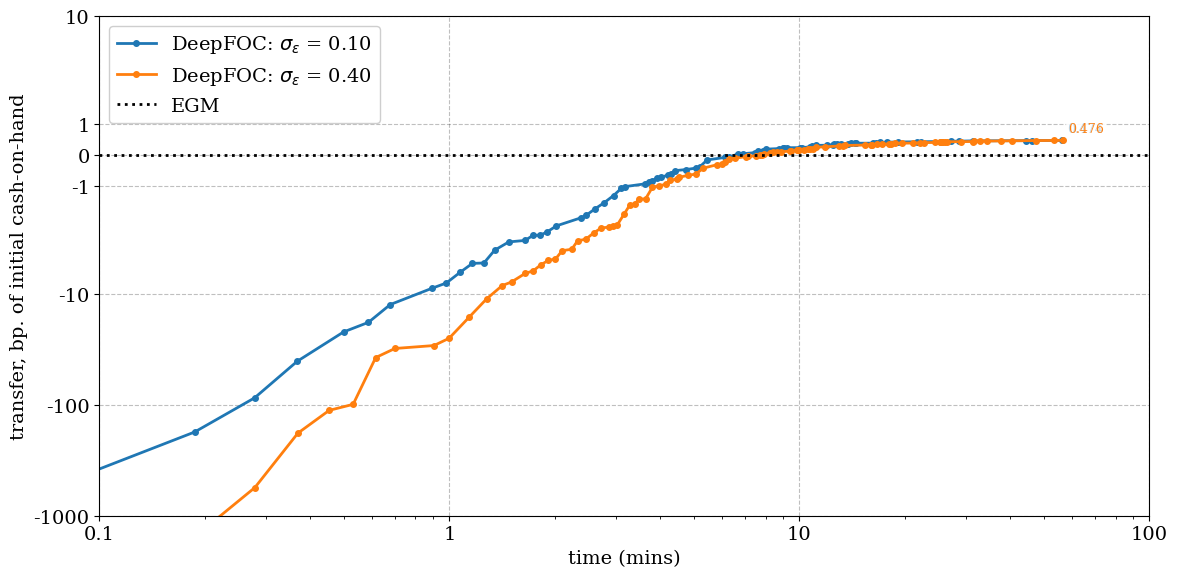

In [34]:
D = 0
for algoname in algonames:

    Dstr = f'{D}D'
    print(algoname,Dstr)
 
    DP = models[('DP',Dstr)]
    specs = {
        (algoname,Dstr):f'{algoname}: $\\sigma_{{\\epsilon}}$ = {models[(algoname,Dstr)].train.epsilon_sigma[0]:.2f}',
        (algoname,Dstr,'moreexplore'):f'{algoname}: $\\sigma_{{\\epsilon}}$ = {models[(algoname,Dstr,"moreexplore")].train.epsilon_sigma[0]:.2f}',
    }
    
    convergence_plot('BufferStockModel',models,specs,DP=DP,do_transfer=True,
                    xlim=xlim,ylim=ylim,legend_ncol=1,
                    folder=folder,postfix=f'_{algoname}_{Dstr}_exploration')
    plt.show()

### 5.2. <a id='toc5_2_'></a>[KKT](#toc0_)

DeepFOC 0D


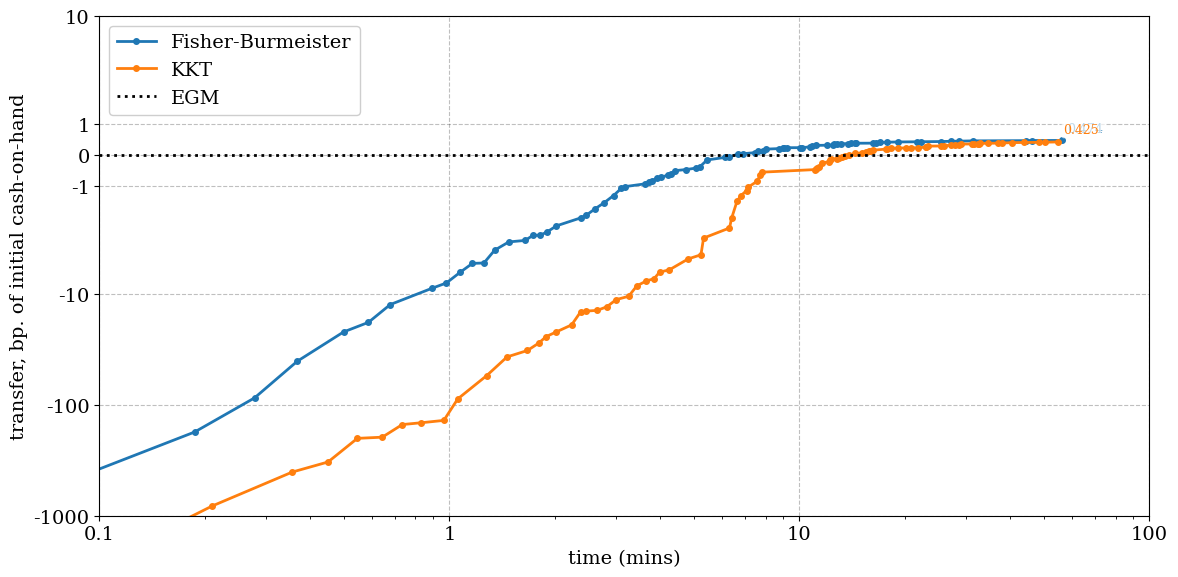

DeepFOC 3D


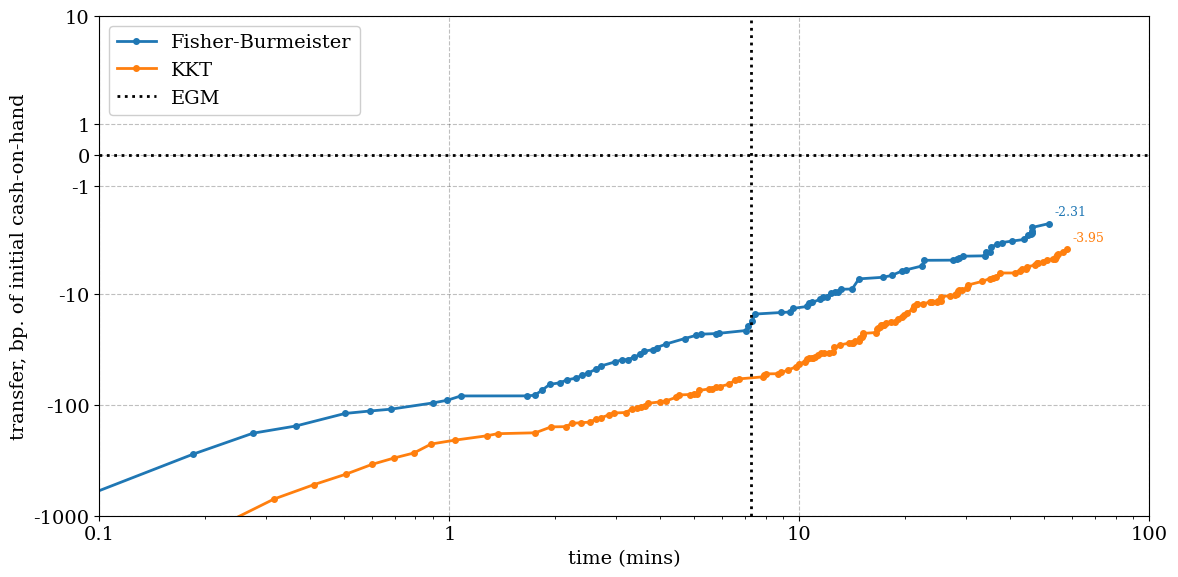

In [35]:
algoname = 'DeepFOC'
for D in Ds:

    Dstr = f'{D}D'
    print(algoname,Dstr)
 
    DP = models[('DP',Dstr)]
    specs = {
        (algoname,Dstr):'Fisher-Burmeister',
        (algoname,Dstr,'KKT'):'KKT',
    }

    convergence_plot('BufferStockModel',models,specs,DP=DP,do_transfer=True,
                    xlim=xlim,ylim=ylim,legend_ncol=1,
                    folder=folder,postfix=f'_{algoname}_{Dstr}_KKT')
    plt.show()

### 5.3. <a id='toc5_3_'></a>[Monte Carlo](#toc0_)

DeepFOC 0D


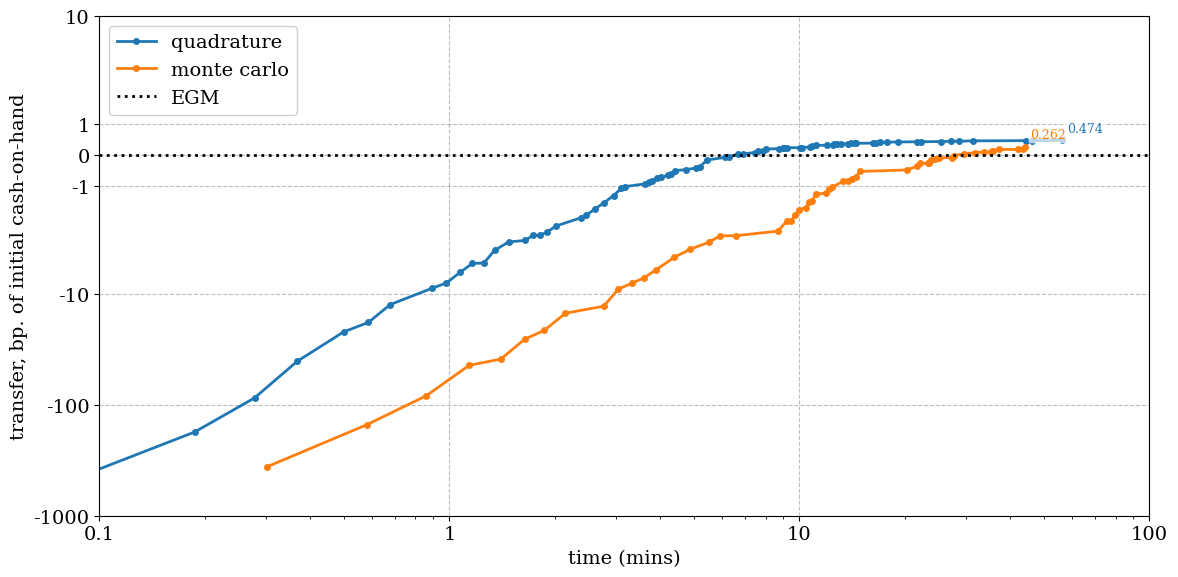

DeepFOC 3D


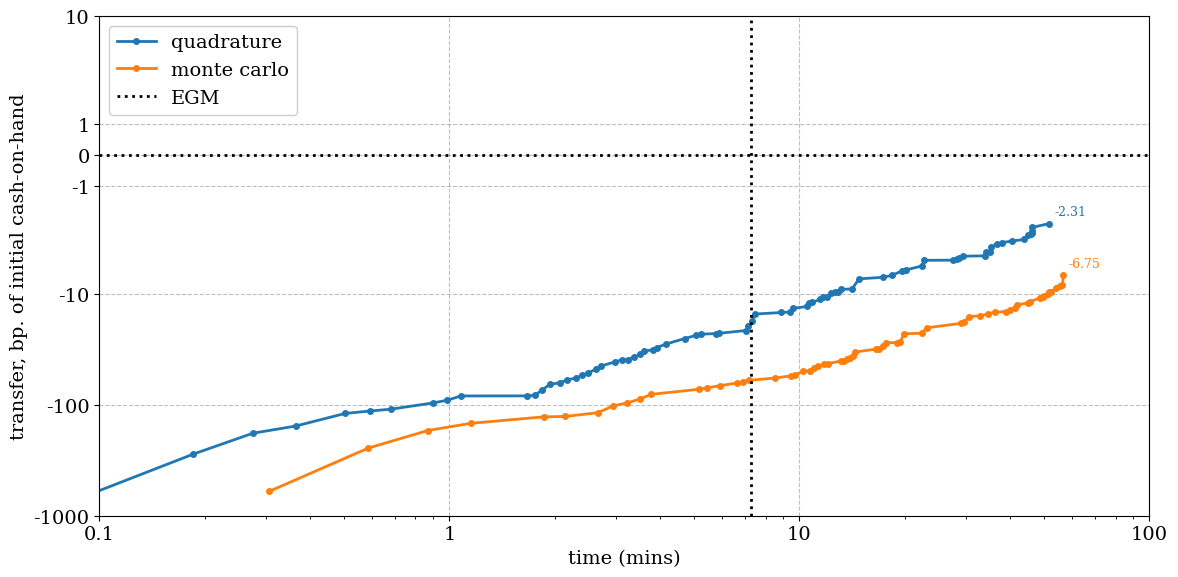

In [36]:
algoname = 'DeepFOC'
for D in Ds:

    Dstr = f'{D}D'
    print(algoname,Dstr)
 
    DP = models[('DP',Dstr)]
    specs = {
        (algoname,Dstr):'quadrature',
        (algoname,Dstr,'MC'):'monte carlo',
    }

    convergence_plot('BufferStockModel',models,specs,DP=DP,do_transfer=True,
                    xlim=xlim,ylim=ylim,legend_ncol=1,
                    folder=folder,postfix=f'_{algoname}_{Dstr}_MC')
    plt.show()

### 5.4. <a id='toc5_4_'></a>[Changing the number of neurons](#toc0_)

DeepSimulate 0D


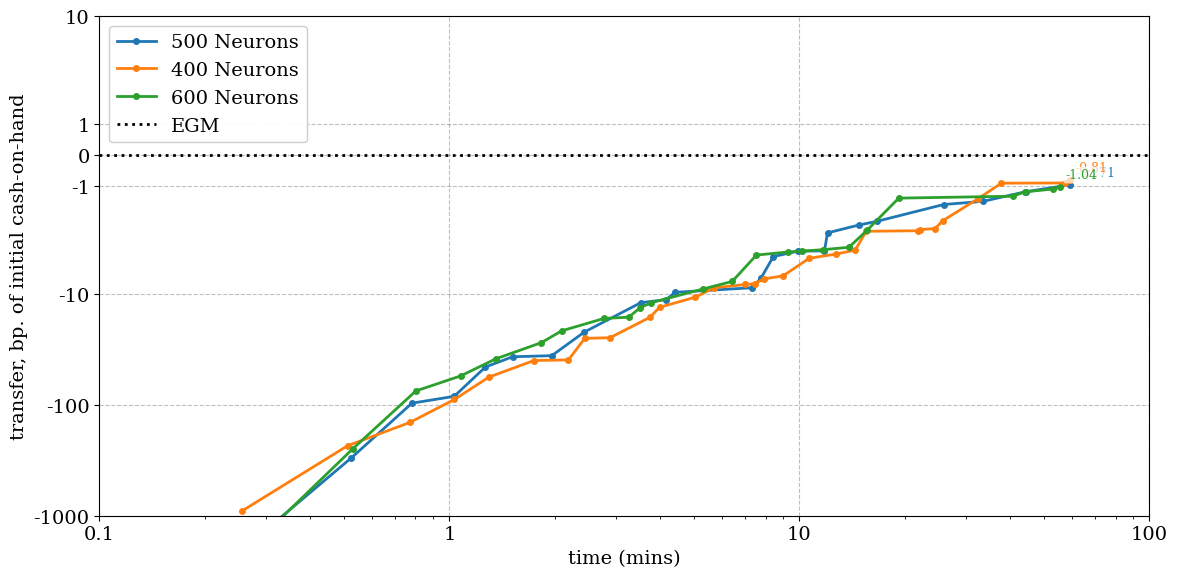

DeepSimulate 3D


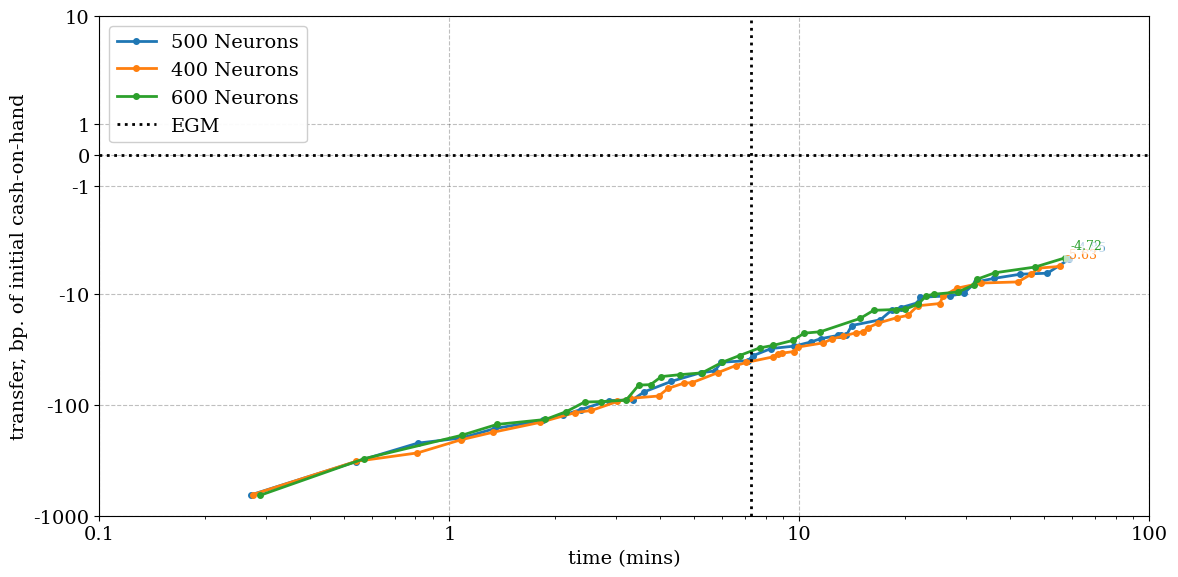

DeepFOC 0D


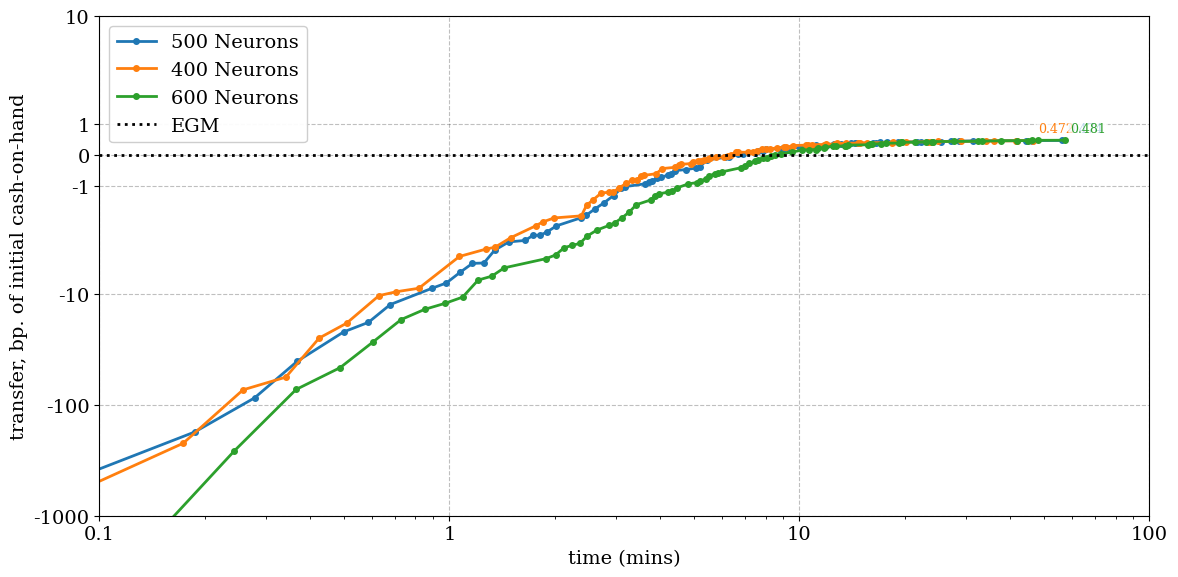

DeepFOC 3D


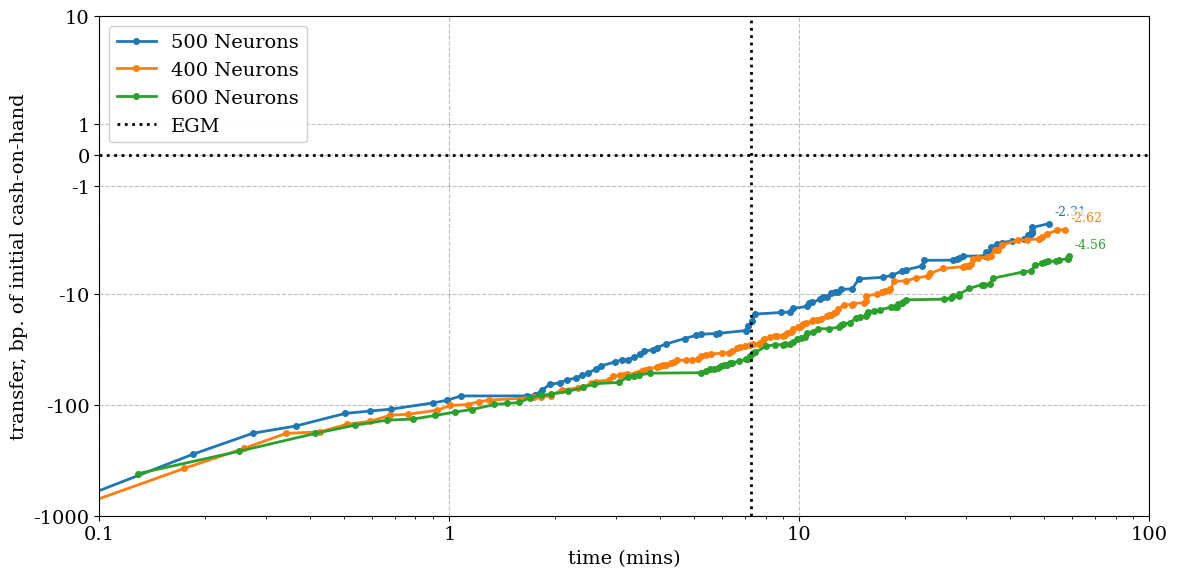

In [37]:
for algoname in algonames:
    for D in Ds:

        Dstr = f'{D}D'
        print(algoname,Dstr)
    
        DP = models[('DP',Dstr)]
        specs = {
            (algoname,Dstr):'500 Neurons',
            (algoname,Dstr,'HyperParNneurons400'):'400 Neurons',
            (algoname,Dstr,'HyperParNneurons600'):'600 Neurons',
        }

        convergence_plot('BufferStockModel',models,specs,DP=DP,do_transfer=True,
                        xlim=xlim,ylim=ylim,legend_ncol=1,
                        folder=folder,postfix=f'_{algoname}_{Dstr}_neurons')
        plt.show()

### 5.5. <a id='toc5_4_'></a>[Continuous time input](#toc0_)

DeepSimulate 0D


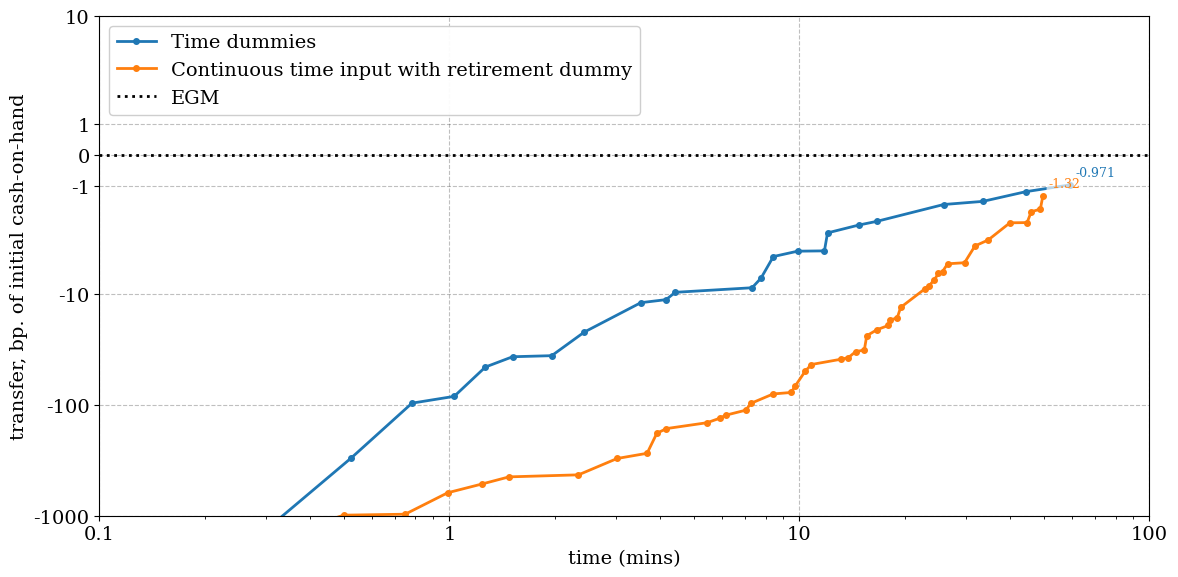

DeepFOC 0D


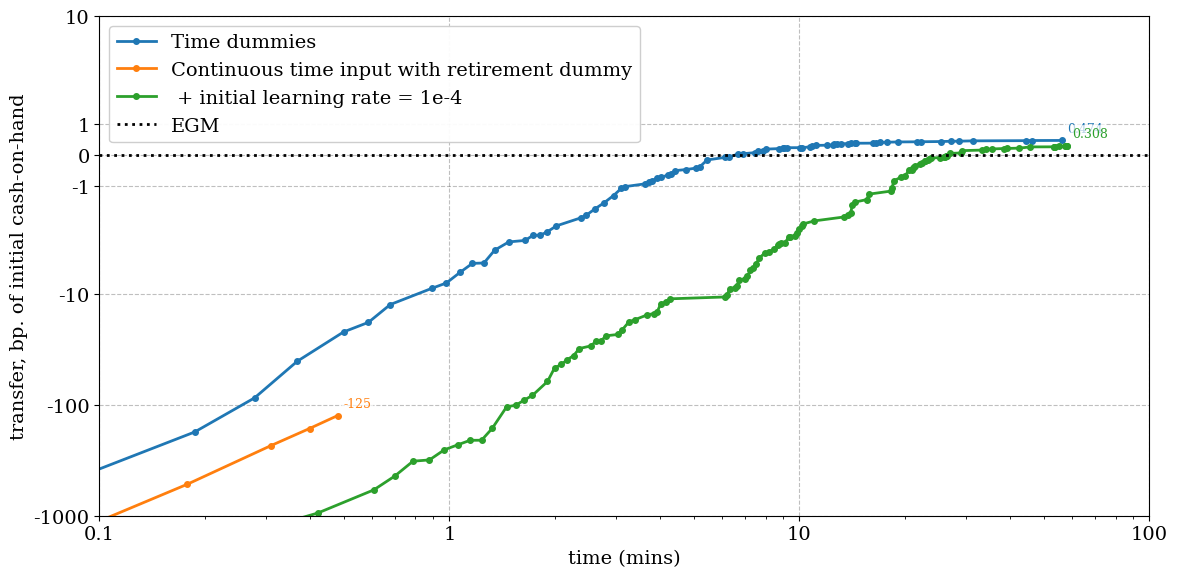

In [38]:
D = 0
algonames_conttime = ['DeepSimulate','DeepFOC']
for algoname in algonames_conttime:

    Dstr = f'{D}D'
    print(algoname,Dstr)

    DP = models[('DP',Dstr)]
    specs = {
        (algoname,Dstr):'Time dummies',
        (algoname,Dstr,'conttime'):'Continuous time input with retirement dummy',
    }
    if algoname == 'DeepFOC':
        specs[(algoname,Dstr,'conttimelowlr')] = ' + initial learning rate = 1e-4',


    convergence_plot('BufferStockModel',models,specs,DP=DP,do_transfer=True,
                    xlim=xlim,ylim=ylim,legend_ncol=1,
                    folder=folder,postfix=f'_{algoname}_{Dstr}_conttime')
    plt.show()

## 6. <a id='toc6_'></a>[Euler Errors](#toc4_2_)                            [&#8593;](#toc0_)

**Note:** Only while working.

In [39]:
from BufferStockModel import select_euler_errors
from BufferStockModelEGM import select_euler_errors_EGM

In [40]:
for D in Ds:

    # DP
    model_DP = models[(f'DP',f'{D}D')]
    euler_error_DP = select_euler_errors_EGM(model_DP)
    I = np.isclose(np.abs(euler_error_DP),0.0)
    model_DP.info['mean_euler_error'] = np.mean(np.log10(np.abs(euler_error_DP[~I])))
    print(f'DP {D}D: {np.mean(I):.4f} share of euler errors are zero')

    # DL and figure
    for i,algoname in enumerate(algonames):
        
        model = get_model(models,algoname,D)
        if model is None: continue
        label = algoname
         
        fig = plt.figure(figsize=(9,6))
        ax = fig.add_subplot(1,1,1)
        
        euler_error = select_euler_errors(model)
        J = np.isclose(np.abs(euler_error),0.0)
        print(f'{algoname} {D}D: {np.mean(J):.4f} share of euler errors are zero')

        model.info['mean_euler_error'] = np.mean(np.log10(np.abs(euler_error[~J])))

        ax.hist(np.log10(np.abs(euler_error_DP)[~I]),bins=100,alpha=0.5,color='grey',density=True,label='EGM')
        ax.axvline(x=model_DP.info['mean_euler_error'],color='grey',linestyle='--',label='EGM, mean')

        ax.hist(np.log10(np.abs(euler_error)[~J]),bins=100,alpha=0.5,color=colors[i],density=True,label=label)
        ax.axvline(x=model.info['mean_euler_error'],color=colors[i],linestyle='--',label=f'{label}, mean')

        ax.set_xlim([-8,0])
        ax.set_xlabel('Euler error')
        ax.set_ylabel('density')

        ax.legend(loc='upper left')

        fig.tight_layout()
        filepath = f'{folder}/BufferStockModel_euler_error_{D}D_{algoname}.svg'
        fig.savefig(filepath)

        if do_display: 
            plt.show()
        else:
            plt.close(fig)
            display(HTML(f'<a href="{filepath}">{filepath}</a>'))


DP 0D: 0.0001 share of euler errors are zero
DeepSimulate 0D: 0.0000 share of euler errors are zero


DeepFOC 0D: 0.0001 share of euler errors are zero


DP 3D: 0.0002 share of euler errors are zero
DeepSimulate 3D: 0.0000 share of euler errors are zero


DeepFOC 3D: 0.0001 share of euler errors are zero


## 7. <a id='toc7_'></a>[Table](#toc0_)

In [41]:
def create_table(DP,models,labels,DP_name='EGM'):

    # define column and row titles
    columns = [DP_name] + labels
    
    rows = [
        'Life-time reward, $R$', 
        'Transfer (bp.) - baseline', 
        ' out-of-sample 1', 
        ' out-of-sample 2', 
        ' out-of-sample 3', 
        ' out-of-sample 4', 
        ' out-of-sample 5', 
        'Mean log10 Euler error',
        '',
        'Total time (m)', 
        '\\,\\,\\,training sample', 
        '\\,\\,\\,update NN', 
        '\\,\\,\\,validation',
        '',
        'Episodes', 
        'Avg. policy epochs', 
    ]

    # create with NaN values
    df = pd.DataFrame(index=rows,columns=columns).fillna('-')  # using '-' to represent missing df for display purposes
    for col in columns:
        df.loc['',col] = ''

    # fill with values
    for model,label in zip([DP]+models,[DP_name]+labels):
       df.loc['Life-time reward, $R$',label] = f"{model.sim.R:.4f}"

    df.loc['Transfer (bp.) - baseline', DP_name] = 0
    for model,label in zip(models,labels):

        transfer = compute_transfer(DP.sim.R_transfer,DP.egm.transfer_grid,
                            model.sim.R)
        
        if not np.isnan(transfer):
            df.loc['Transfer (bp.) - baseline', label] = f"{100**2*transfer:.0f}"
        else:
            df.loc['Transfer (bp.) - baseline', label] = '-'

    for model,label in zip([DP]+models,[DP_name]+labels):
        try:
            df.loc['Mean log10 Euler error',label] = f"{model.info['mean_euler_error']:.1f}"
        except:
            pass

    for i in range(5):
        df.loc[f' out-of-sample {i+1}', DP_name] = 0
        for model,label in zip(models,labels):

            transfer = compute_transfer(DP.sim.R_transfers[i],DP.egm.transfer_grid,
                                model.info['Rs'][i])
            
            if not np.isnan(transfer):
                df.loc[f' out-of-sample {i+1}', label] = f"{100**2*transfer:.0f}"
            else:
                df.loc[f' out-of-sample {i+1}', label] = '-'

    for model,label in zip([DP]+models,[DP_name]+labels):
        df.loc['Total time (m)', label] = f"{model.info['time']/60:.2f}"

    df.loc['\\,\\,\\,training sample',DP_name] = '-'
    for model,label in zip(models,labels):
        time_rel = model.info['time._simulate_training_sample'] / model.info['time']
        df.loc['\\,\\,\\,training sample', label] = f"{100*time_rel:.1f}\\%"

    df.loc['\\,\\,\\,update NN',DP_name] = '-'
    for model,label in zip(models,labels):
        time_rel = model.info['time.update_NN'] / model.info['time']
        df.loc['\\,\\,\\,update NN',label] = f"{100*time_rel:.1f}\\%"

    df.loc['\\,\\,\\,validation',DP_name] = '-'
    for model,label in zip(models,labels):
        time_rel = model.info['time.update_best'] / model.info['time']
        df.loc['\\,\\,\\,validation', label] = f"{100*time_rel:.1f}\\%"     

    df.loc['Episodes', DP_name] = 1
    for model,label in zip(models,labels):
        df.loc['Episodes', label] = model.info['iter']

    df.loc['Avg. policy epochs', DP_name] = '-'
    for model,label in zip(models,labels):
        df.loc['Avg. policy epochs', label] = f"{model.info[('policy_epochs','mean')]:.1f}"

    return df

In [42]:
for D in Ds:

    print(f'{D = }')

    # a. select
    DP = models[('DP',f'{D}D')]
    models_ = [get_model(models,algoname,D) for algoname in algonames]
    labels = [algoname for algoname in algonames]

    # b. table
    df = create_table(DP,models_,labels)
    display(df)

    # c. save
    filename = f'{folder}/BufferStockModel_table_{D}D.tex'
    df.style.to_latex(filename,hrules=True)    

D = 0


,EGM,DeepSimulate,DeepFOC
"Life-time reward, $R$",2.0649,2.0648,2.0650
Transfer (bp.) - baseline,0,-1,0
out-of-sample 1,0,-1,0
out-of-sample 2,0,-1,1
out-of-sample 3,0,-1,1
out-of-sample 4,0,-1,1
out-of-sample 5,0,-1,1
Mean log10 Euler error,-4.4,-3.0,-3.8
,,,
Total time (m),0.00,60.01,60.01


D = 3


,EGM,DeepSimulate,DeepFOC
"Life-time reward, $R$",2.8586,2.8581,2.8583
Transfer (bp.) - baseline,0,-5,-2
out-of-sample 1,0,-4,-1
out-of-sample 2,0,-3,-0
out-of-sample 3,0,-5,-2
out-of-sample 4,0,-4,-0
out-of-sample 5,0,-5,-1
Mean log10 Euler error,-4.4,-2.8,-3.4
,,,
Total time (m),7.25,60.01,60.02


## 8. <a id='toc8_'></a>[Backward](#toc0_)

### 8.1. <a id='toc8_1_'></a>[Pure in 0D](#toc0_)

In [43]:
DP = get_model(models,'DP',0)
for algoname in ['DeepFOC','DeepFOCBackward_pure']:
    model = get_model(models,algoname,0)
    R = model.sim.R
    transfer = compute_transfer(DP.sim.R_transfer,DP.egm.transfer_grid,R)    
    print(f'{algoname:30s}: 0D: R = {R:.5f} -> transfer = {100**2*transfer:.0f} bp.')

DeepFOC                       : 0D: R = 2.06498 -> transfer = 0 bp.
DeepFOCBackward_pure          : 0D: R = 1.54027 -> transfer = -3985 bp.


DeepFOCBackward_pure 0


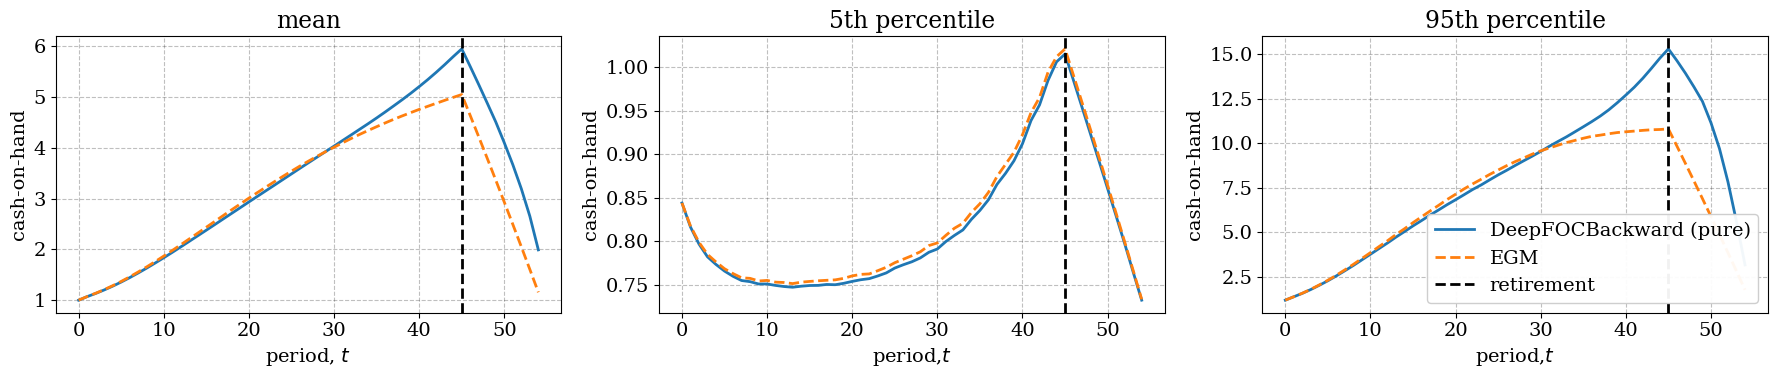

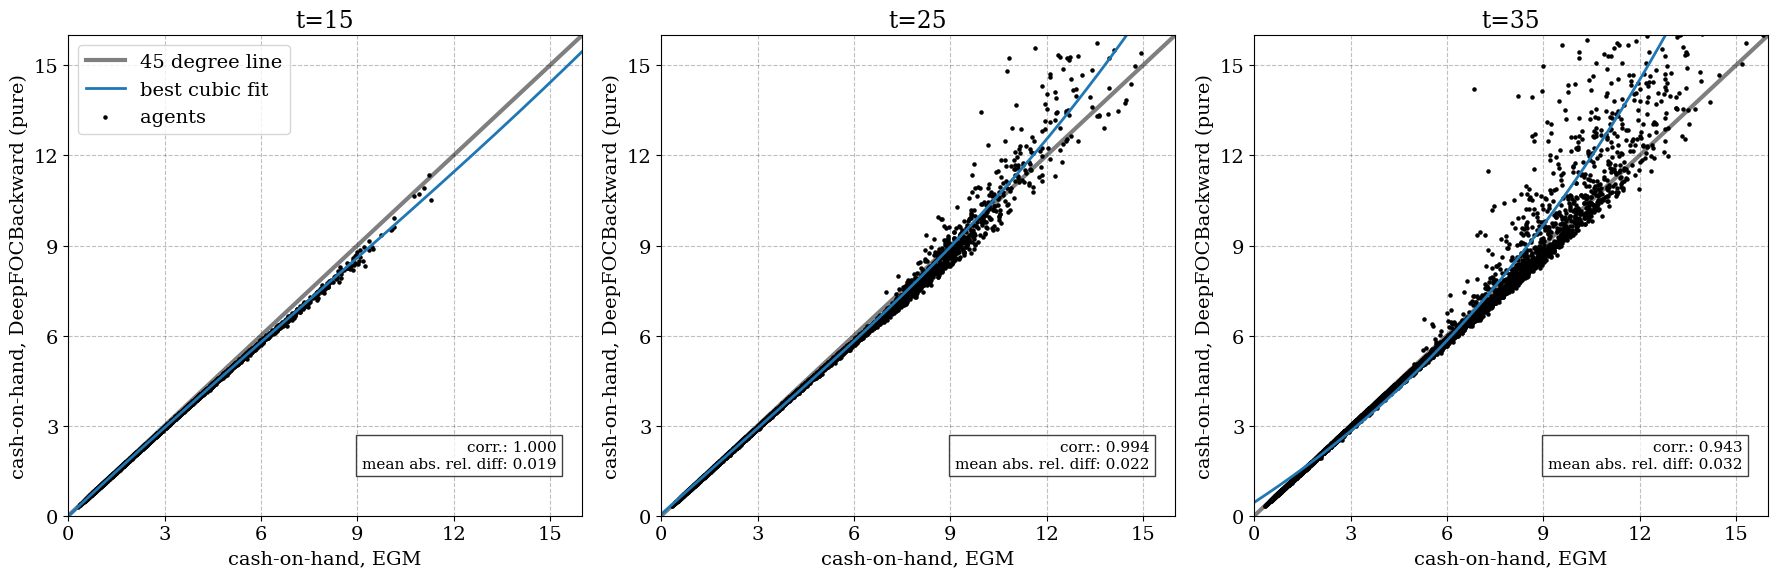

In [44]:
varname = 'm'
D = 0
do_display = True
plot_life_cycle_wide(varname,'DeepFOCBackward_pure',D,models,do_display,label='DeepFOCBackward (pure)')
plot_cross_section('DeepFOCBackward_pure',D,models,basename='DP',label='DeepFOCBackward (pure)')

### 8.2. <a id='toc8_2_'></a>[Refinement in 3D](#toc0_)

In [45]:
DP = get_model(models,'DP',3)
backward = {}
for algoname in ['DeepFOC','DeepFOC_short','DeepFOCBackward_short']:
    
    model = get_model(models, algoname, 3)
    R = model.sim.R
    transfer = compute_transfer(DP.sim.R_transfer,DP.egm.transfer_grid,R)    
    print(f'{algoname:25s}: 3D: R = {R:.5f} -> transfer = {100**2*transfer:.0f} bp.')

    if algoname == 'DeepFOC_short':
        backward['t_beg'] = model.train.K_time
        backward['transfer_beg'] = transfer
    elif algoname == 'DeepFOCBackward_short':
        backward['transfer_end'] = transfer
        backward['t_end'] = backward['t_beg']+model.train.K_time


DeepFOC                  : 3D: R = 2.85834 -> transfer = -2 bp.
DeepFOC_short            : 3D: R = 2.85713 -> transfer = -13 bp.
DeepFOCBackward_short    : 3D: R = 2.85817 -> transfer = -4 bp.


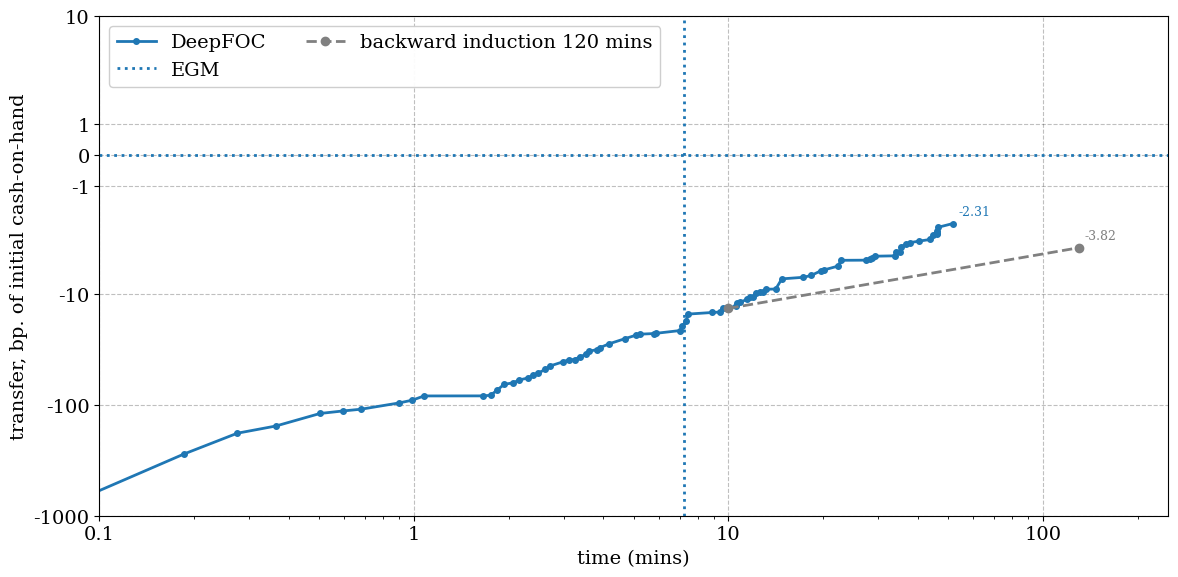

In [46]:
D = 3
algoname = 'DeepFOC'
xlim_low = [0.1,250]

DP = {('DP',f'{D}D'):f'EGM'}
specs = {(algoname,f'{D}D'):f'{algoname}'}

convergence_plot('BufferStockModel',models,specs,DP=DP,backward=backward,do_transfer=True,
                    xlim=xlim_low,ylim=ylim,
                    folder=folder,postfix=f'_{D}D_{algoname}Backward')  

DeepFOC_short 3


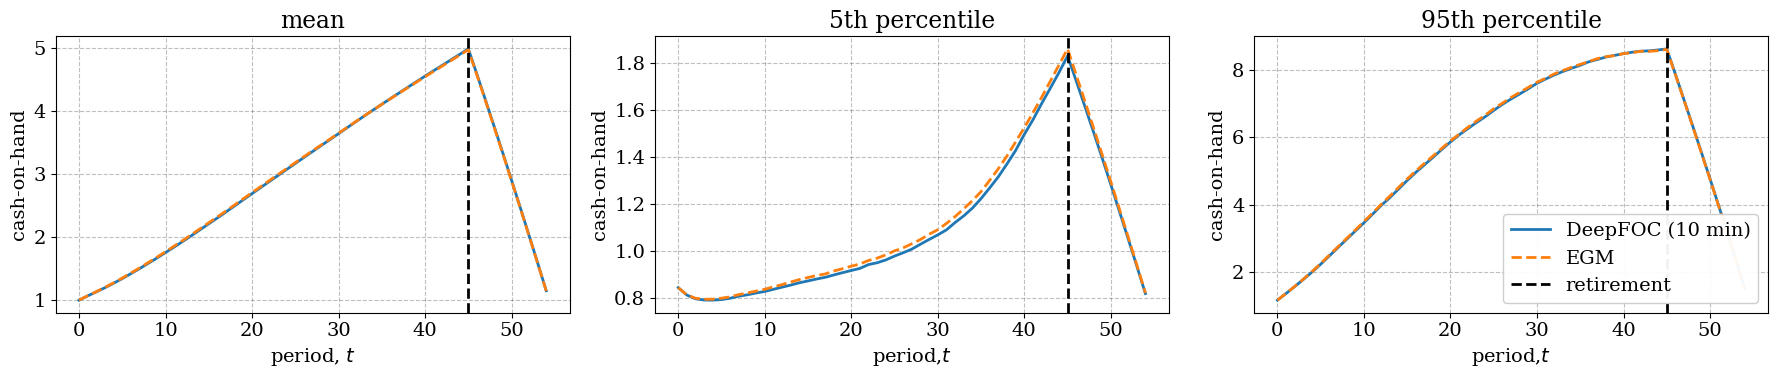

DeepFOCBackward_short 3


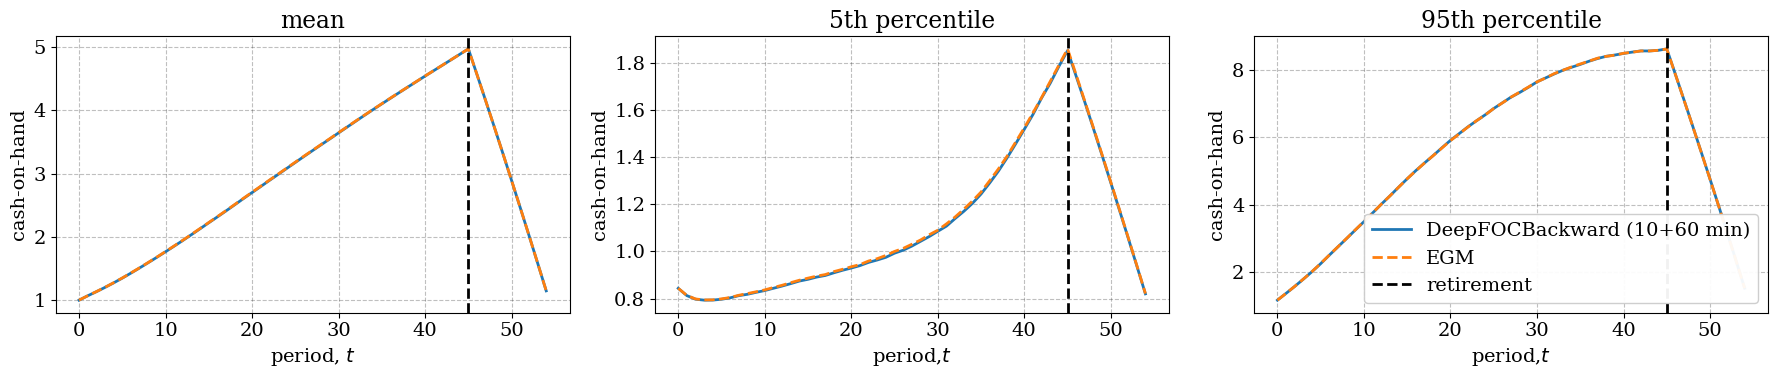

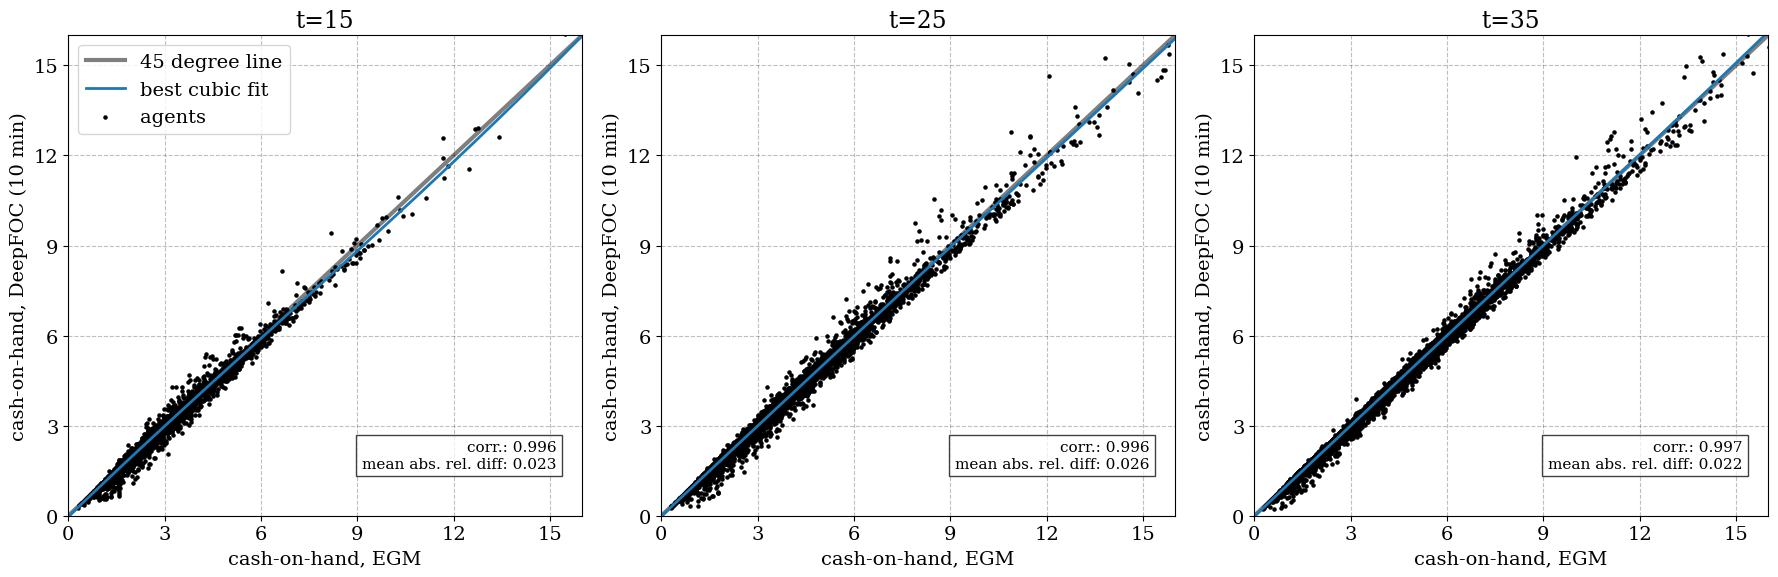

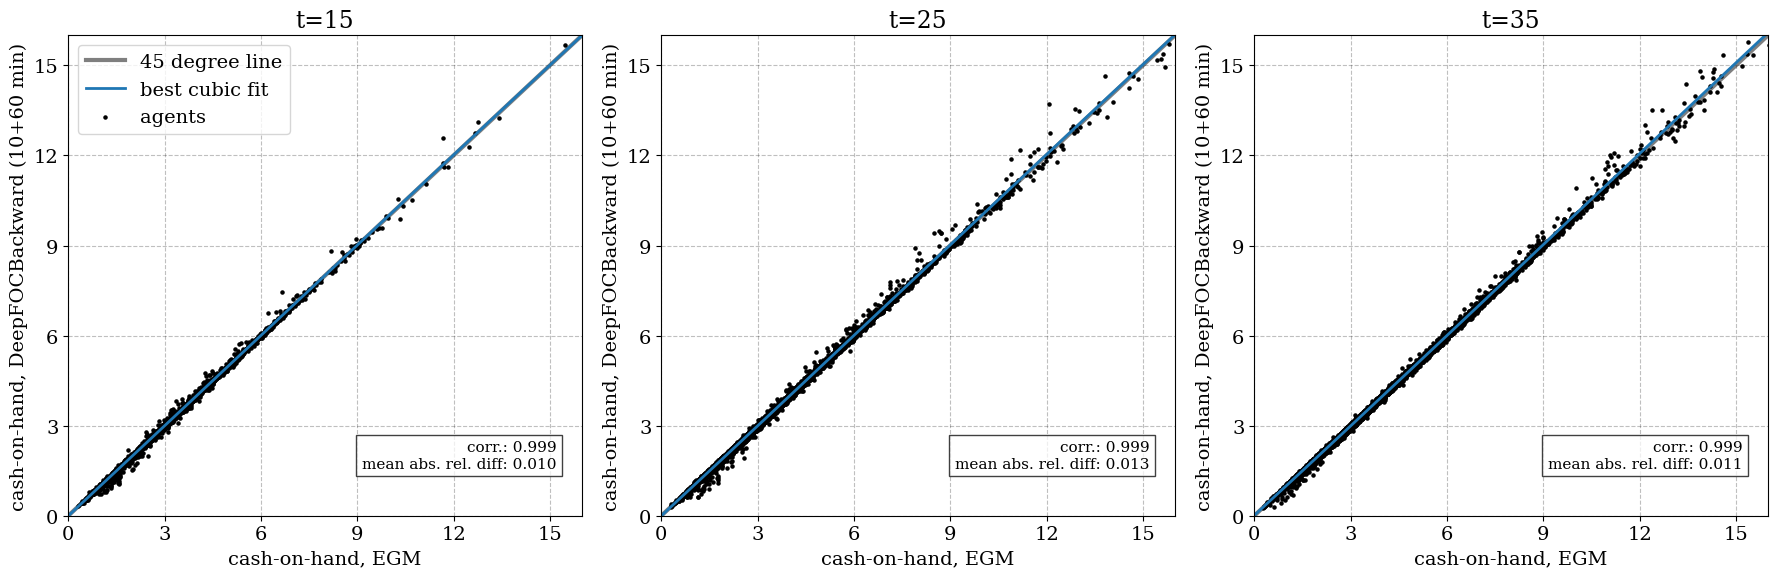

In [47]:
varname = 'm'
D = 3
do_display = True
plot_life_cycle_wide(varname,'DeepFOC_short',D,models,do_display,label='DeepFOC (10 min)')
plot_life_cycle_wide(varname,'DeepFOCBackward_short',D,models,do_display,label='DeepFOCBackward (10+60 min)')
plot_cross_section('DeepFOC_short',D,models,basename='DP',label='DeepFOC (10 min)')
plot_cross_section('DeepFOCBackward_short',D,models,basename='DP',label='DeepFOCBackward (10+60 min)')